# MACHINE LEARNING-BASED NETWORK INTRUSION DETECTION

# Author: Valérie Andoulsi

**Domain:** Cybersecurity  
**Use case:** Network intrusion detection  
**Dataset:** UNSW-NB15  
**Task:** Supervised binary classification  
**Objective:** Develop and evaluate machine learning models to classify individual network traffic flows as normal or malicious.

# 1. Problem understanding & framing

## 1.1 Business problem

Modern organizations generate large volumes of network traffic through legitimate activities such as communications, online transactions and data transfers. This traffic can also contain malicious activity that may compromise systems, disrupt services or contribute to security incidents.

Detecting malicious network traffic is therefore an important cybersecurity challenge. The volume and complexity of network activity can make continuous manual monitoring difficult. Automated detection systems can support security teams by identifying potentially malicious traffic, but they can also generate false-positive alerts that require further investigation.

The business problem addressed in this project is to improve the detection of potentially malicious network traffic while maintaining a manageable volume of false alerts.

The intended outcome is a machine-learning-based detection capability that can help identify potentially malicious network activity and support its prioritisation for further investigation.


## 1.2 Data science problem

The business problem is translated into a supervised machine learning problem: determining whether a network traffic flow should be classified as normal or malicious based on its observed characteristics.

The UNSW-NB15 dataset provides labelled network traffic observations that can be used to train and evaluate classification models. The `label` variable identifies whether an observation corresponds to normal traffic or malicious activity.

This makes the problem a supervised binary classification task. The model has two possible outcomes:

0 → Normal traffic

1 → Malicious traffic

The objective is to develop models that can distinguish between the two classes and generalize their predictions to previously unseen network traffic.

In this cybersecurity context, predictive performance cannot be considered in isolation. The detection of malicious traffic should be as effective as possible while avoiding an excessive number of false-positive alerts.

## 1.3 Success metrics

In a network intrusion detection context, model performance cannot be assessed using accuracy alone. The consequences of misclassification are asymmetric: failing to detect malicious traffic may allow an intrusion to remain undetected, while incorrectly classifying legitimate traffic as malicious may generate unnecessary alerts.

For this reason, the project evaluates model performance using a set of complementary technical metrics. These metrics are selected to assess both the ability to detect malicious traffic and the quality of the resulting classifications.

**Recall** is used as the primary success metric because it measures the proportion of malicious network flows that are correctly detected. A high recall reduces the number of malicious observations that are missed by the model.

**Precision** complements recall by measuring the proportion of observations classified as malicious that are actually malicious. It is therefore relevant for assessing the proportion of model-generated positive predictions that correspond to malicious traffic.

**F1-score** combines precision and recall into a single measure and provides a balanced assessment when both missed malicious traffic and false-positive classifications are relevant.

**PR-AUC** evaluates the precision-recall trade-off across different classification thresholds. It is particularly relevant when the detection of the malicious class is a primary concern.

**ROC-AUC** measures the model's ability to discriminate between normal and malicious traffic across classification thresholds. It provides a broader measure of the model's ranking and discrimination capability.

**False Positive Rate (FPR)** measures the proportion of legitimate network flows that are incorrectly classified as malicious. Although it is a technical classification metric, it is particularly important in this project because a high FPR may translate into a large number of unnecessary alerts requiring investigation.

The evaluation therefore follows a **multi-metric approach**. Recall provides the primary measure of malicious-traffic detection, while Precision, F1-score, PR-AUC, ROC-AUC and FPR provide complementary information about classification quality and false-positive behaviour. No single metric is considered sufficient on its own to characterize model performance.


## 1.4 Business and operational KPIs


Technical machine learning metrics need to be translated into indicators that are meaningful from an operational perspective. In this project, the operational objective is to improve the detection of malicious network traffic while maintaining a manageable volume of false-positive alerts for security analysts.

The following business and operational KPIs are used to interpret model performance:

**Malicious Traffic Detection Rate**: corresponds to Recall and represents the percentage of malicious network flows that are correctly identified by the model. It provides an operational view of the model's ability to detect malicious activity.

**Undetected Attack Rate**: corresponds to \(1 - Recall\) and represents the percentage of malicious network flows that are incorrectly classified as normal. It provides an operational view of the residual risk associated with missed malicious activity.

**False Alert Rate**: corresponds to the False Positive Rate (FPR) and represents the percentage of legitimate network flows that are incorrectly classified as malicious. A higher false alert rate may increase the number of events requiring further investigation.

**False Alert Volume**: represents the number of legitimate network flows incorrectly classified as malicious. Unlike the False Alert Rate, which is expressed as a percentage, this indicator provides an absolute measure of the potential number of unnecessary alerts generated by the model.

**Alerts per 10,000 Network Flows**: provides a normalized representation of the potential alert volume by estimating how many network flows may be flagged for investigation for every 10,000 network flows processed. This is a derived operational indicator based on the false-alert volume and is used to facilitate interpretation and comparison across models.

These indicators provide two complementary operational perspectives: the proportion of malicious traffic that may remain undetected and the potential volume of legitimate traffic that may generate unnecessary alerts.

The project therefore evaluates model performance through a combination of technical success metrics and operational indicators rather than optimizing a single measure in isolation.


## 1.5 Project scope, key assumptions and limitations


This project focuses on the development and evaluation of supervised machine learning models for the binary classification of individual network traffic flows using the UNSW-NB15 dataset. The classification task distinguishes between normal network traffic and malicious network traffic.

The project covers the main stages of the machine learning lifecycle relevant to this problem, including data understanding, data preprocessing, exploratory data analysis, feature engineering, feature selection, dimensionality reduction, model development, model comparison, model evaluation, and model explainability.

Several supervised learning algorithms are considered and compared using the predefined technical success metrics and business and operational indicators established in the previous sections.

The analysis is conducted within the characteristics and experimental context of the UNSW-NB15 dataset. The dataset is considered suitable for investigating the defined network intrusion detection problem within the scope of this academic project.

The traffic patterns and attack behaviours represented in the dataset may not fully capture the diversity and complexity of network traffic encountered in different real-world environments. Model performance obtained on UNSW-NB15 may therefore not directly generalize to other network environments, infrastructures, or operational conditions.

The project focuses on the classification of individual network traffic flows. It does not aim to develop a complete real-time Security Operations Center (SOC) solution, an automated incident-response system, or an end-to-end cybersecurity monitoring platform.

Production deployment, continuous model monitoring, and MLOps implementation are outside the core scope of the capstone. The project instead focuses on the experimental development, evaluation, comparison, and critical analysis of machine learning approaches for network intrusion detection.

Finally, the evaluation considers the operational implications of classification errors. False negatives represent malicious network flows that remain undetected and therefore relate to residual detection risk. False positives represent legitimate network flows incorrectly classified as malicious and may increase the volume of alerts requiring investigation.

The results should therefore be interpreted as an experimental evaluation of machine learning approaches on the UNSW-NB15 dataset rather than as evidence of production readiness or direct applicability to all real-world network environments.


# 2. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning - preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Machine learning - feature selection & dimensionality reduction
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA

# Machine learning - models
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Machine learning - cross-validation and model selection
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
    GridSearchCV
)

# Machine learning - model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Model explainability
import shap

# Utilities
import joblib
import warnings

warnings.filterwarnings("ignore")

In [2]:
import pandas
import numpy
import matplotlib
import seaborn
import sklearn
import xgboost
import shap
import joblib

print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("shap:", shap.__version__)
print("joblib:", joblib.__version__)

pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
xgboost: 3.4.1
shap: 0.52.0
joblib: 1.6.0


# 3. Data collection & understanding

This section presents and assesses the UNSW-NB15 dataset used for the network intrusion detection problem defined in Chapter 1.

The analysis first documents the dataset source, structure, variables, data types, and target variable. It then assesses the main data quality characteristics, including missing values, duplicate observations, class distribution, variable distributions, and potential outliers.

A detailed data dictionary is provided to document the variables, their types, meanings, and observed value ranges or categories.

The findings from this stage are used to inform the data preprocessing, exploratory data analysis, and feature engineering decisions developed in the following sections.


## 3.1 Dataset source

**Dataset:** UNSW-NB15  
**Domain:** Cybersecurity / Network Intrusion Detection  
**Source:** UNSW Canberra  
**Target variable:** `label`


The dataset used in this project is the **UNSW-NB15 dataset**, a publicly available network traffic dataset developed by the **Australian Centre for Cyber Security (ACCS) at UNSW Canberra**.

UNSW-NB15 was created to support research in network security and intrusion detection. It contains network traffic observations representing both **normal activities and malicious activities**, making it suitable for the supervised binary classification problem defined in Chapter 1.

The dataset was generated in a controlled experimental environment designed to capture a range of network behaviours and attack activities. This provides labelled observations that can be used to develop and evaluate machine learning models for network intrusion detection.

For this project, the dataset is used to classify individual network traffic flows into two classes:

<br>

- **0 — Normal traffic**
- **1 — Malicious traffic**

<br>

The `label` variable is therefore used as the target variable for the binary classification task.

The UNSW-NB15 dataset was selected because it provides labelled network traffic observations with a combination of numerical and categorical characteristics that can be used to investigate machine learning approaches for intrusion detection. Its public availability also supports the reproducibility of the academic analysis.

However, because the dataset reflects traffic and attack behaviours generated within a controlled experimental setting, its characteristics may differ from those observed in other real-world network environments. This limitation is considered when interpreting model generalization later in the project.

## 3.2 Load dataset

The UNSW-NB15 dataset is provided through separate training and testing files. The two partitions are loaded separately and remain distinct throughout the initial data understanding and preparation stages.

The training dataset is used for data exploration and model development, while the testing dataset is reserved for the independent evaluation of the final models.

Keeping the provided training and testing partitions separate prevents information from the independent test set from being used during model development.

In [3]:
from google.colab import drive

drive.mount('/content/drive')


train_path = "/content/drive/MyDrive/AI AND ML/Capstone ML/UNSW_NB15_training-set.csv"
test_path = "/content/drive/MyDrive/AI AND ML/Capstone ML/UNSW_NB15_testing-set.csv"

# Load datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Mounted at /content/drive
Training set shape: (175341, 45)
Testing set shape: (82332, 45)


## 3.3 Dataset overview

This subsection provides an overview of the structure and content of the dataset.

A description of the variables is also provided to clarify the meaning of the information contained in the dataset.

This step is important for understanding what each variable represents before assessing data quality or preparing the features for machine learning.

In [4]:
# Dataset dimensions
print("TRAINING SET")
print(f"Number of observations: {train_df.shape[0]:,}")
print(f"Number of features: {train_df.shape[1]}")

print("\nTESTING SET")
print(f"Number of observations: {test_df.shape[0]:,}")
print(f"Number of features: {test_df.shape[1]}")

print("\nTOTAL DATASET")
print(f"Total observations: {len(train_df) + len(test_df):,}")

TRAINING SET
Number of observations: 175,341
Number of features: 45

TESTING SET
Number of observations: 82,332
Number of features: 45

TOTAL DATASET
Total observations: 257,673


In [5]:
# First five observations
print("\nFIRST FIVE OBSERVATIONS")
display(train_df.head())



FIRST FIVE OBSERVATIONS


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [6]:
# Column names
print("\nFEATURES AND VARIABLES")
for i, column in enumerate(train_df.columns, 1):
    print(f"{i}. {column}")


FEATURES AND VARIABLES
1. id
2. dur
3. proto
4. service
5. state
6. spkts
7. dpkts
8. sbytes
9. dbytes
10. rate
11. sttl
12. dttl
13. sload
14. dload
15. sloss
16. dloss
17. sinpkt
18. dinpkt
19. sjit
20. djit
21. swin
22. stcpb
23. dtcpb
24. dwin
25. tcprtt
26. synack
27. ackdat
28. smean
29. dmean
30. trans_depth
31. response_body_len
32. ct_srv_src
33. ct_state_ttl
34. ct_dst_ltm
35. ct_src_dport_ltm
36. ct_dst_sport_ltm
37. ct_dst_src_ltm
38. is_ftp_login
39. ct_ftp_cmd
40. ct_flw_http_mthd
41. ct_src_ltm
42. ct_srv_dst
43. is_sm_ips_ports
44. attack_cat
45. label


**Variables description**

The UNSW-NB15 dataset contains variables describing different characteristics of network traffic flows, including connection duration, protocols, packet and byte volumes, timing characteristics, TCP-related information and contextual traffic statistics.

The following table provides a description of the variables used in the dataset and their role in characterizing network traffic.


<br>



| Variable | Type | Description | Role in the project |
|---|---|---|---|
| `id` | Integer | Unique identifier assigned to the network flow | Identifier; excluded from predictive modelling |
| `dur` | Numerical | Duration of the network connection | Predictive feature |
| `proto` | Categorical | Network protocol used by the connection | Predictive feature; requires encoding |
| `service` | Categorical | Network service associated with the connection | Predictive feature; requires encoding |
| `state` | Categorical | State of the network connection | Predictive feature; requires encoding |
| `spkts` | Numerical | Number of packets transmitted from the source | Predictive feature |
| `dpkts` | Numerical | Number of packets transmitted to the destination | Predictive feature |
| `sbytes` | Numerical | Total number of bytes transmitted from the source | Predictive feature |
| `dbytes` | Numerical | Total number of bytes transmitted to the destination | Predictive feature |
| `rate` | Numerical | Data transmission rate during the network flow | Predictive feature |
| `sttl` | Numerical | Time To Live (TTL) value observed from the source | Predictive feature |
| `dttl` | Numerical | Time To Live (TTL) value observed from the destination | Predictive feature |
| `sload` | Numerical | Amount of data transmitted per second from the source | Predictive feature |
| `dload` | Numerical | Amount of data transmitted per second to the destination | Predictive feature |
| `sloss` | Numerical | Number of packets lost from the source | Predictive feature |
| `dloss` | Numerical | Number of packets lost to the destination | Predictive feature |
| `sinpkt` | Numerical | Average time between packets transmitted from the source | Predictive feature |
| `dinpkt` | Numerical | Average time between packets transmitted to the destination | Predictive feature |
| `sjit` | Numerical | Variation in packet timing from the source (source jitter) | Predictive feature |
| `djit` | Numerical | Variation in packet timing at the destination (destination jitter) | Predictive feature |
| `swin` | Numerical | Source TCP window size | Predictive feature |
| `stcpb` | Numerical | Source TCP base sequence number | Predictive feature |
| `dtcpb` | Numerical | Destination TCP base sequence number | Predictive feature |
| `dwin` | Numerical | Destination TCP window size | Predictive feature |
| `tcprtt` | Numerical | TCP round-trip time between source and destination | Predictive feature |
| `synack` | Numerical | Time between the SYN and SYN-ACK packets | Predictive feature |
| `ackdat` | Numerical | Time between the SYN-ACK and ACK packets | Predictive feature |
| `smean` | Numerical | Mean packet size transmitted from the source | Predictive feature |
| `dmean` | Numerical | Mean packet size transmitted to the destination | Predictive feature |
| `trans_depth` | Numerical | Depth of the connection within an HTTP transaction | Predictive feature |
| `response_body_len` | Numerical | Length of the HTTP response body | Predictive feature |
| `ct_srv_src` | Numerical | Number of connections involving the same service and source in the relevant time window | Predictive feature |
| `ct_state_ttl` | Numerical | Number of connections sharing the same state and TTL characteristics | Predictive feature |
| `ct_dst_ltm` | Numerical | Number of connections involving the same destination in the relevant time window | Predictive feature |
| `ct_src_dport_ltm` | Numerical | Number of connections from the same source to the same destination port in the relevant time window | Predictive feature |
| `ct_dst_sport_ltm` | Numerical | Number of connections to the same destination from the same source port in the relevant time window | Predictive feature |
| `ct_dst_src_ltm` | Numerical | Number of connections between the same source and destination in the relevant time window | Predictive feature |
| `is_ftp_login` | Numerical | Indicator of whether an FTP login was performed | Predictive feature |
| `ct_ftp_cmd` | Numerical | Number of FTP commands associated with the connection | Predictive feature |
| `ct_flw_http_mthd` | Numerical | Number of HTTP methods associated with the connection | Predictive feature |
| `ct_src_ltm` | Numerical | Number of connections involving the same source in the relevant time window | Predictive feature |
| `ct_srv_dst` | Numerical | Number of connections involving the same service and destination | Predictive feature |
| `is_sm_ips_ports` | Numerical | Indicator of whether the source and destination IP addresses and ports are identical | Predictive feature |
| `attack_cat` | Categorical | Category of attack associated with the network flow | Analysis variable; excluded from predictive modelling to avoid target leakage |
| `label` | Binary | Indicates whether the network flow is normal (`0`) or malicious (`1`) | Target variable |


## 3.4 Data quality assessment

This subsection assesses the main data quality characteristics of the training dataset before preprocessing. The analysis examines data types, missing values, duplicate observations, and the number of unique values across variables.

These checks are used to identify potential data quality issues and determine whether specific preprocessing or data-cleaning steps may be required before model development.

In [7]:
# Data types and dataset information

print("\nDATA TYPES AND DATASET INFORMATION")

train_df.info()


DATA TYPES AND DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss          

In [8]:
# Missing values

print("\nMISSING VALUES PER COLUMN")

display(train_df.isnull().sum())


MISSING VALUES PER COLUMN


,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


In [9]:
# Duplicate rows

print("\nDUPLICATE ROWS")

print(train_df.duplicated().sum())


DUPLICATE ROWS
0


In [10]:
# Number of unique values

print("\nNUMBER OF UNIQUE VALUES PER COLUMN")

display(train_df.nunique())


NUMBER OF UNIQUE VALUES PER COLUMN


,0
id,175341
dur,74039
proto,133
service,13
state,9
spkts,480
dpkts,443
sbytes,7214
dbytes,6660
rate,76991


## 3.5 Feature distributions & outliers

This subsection examines the descriptive statistics and distributions of the numerical features, including their central tendency, variability, observed ranges, and overall distribution patterns. Potential extreme observations are then identified using a statistical outlier detection approach.

In [11]:
# Descriptive statistics of numerical features

numerical_features = train_df.select_dtypes(include=np.number).columns.tolist()

print("NUMBER OF NUMERICAL FEATURES")
print(len(numerical_features))

print("\nDESCRIPTIVE STATISTICS OF NUMERICAL FEATURES")

display(train_df[numerical_features].describe().T)

NUMBER OF NUMERICAL FEATURES
41

DESCRIPTIVE STATISTICS OF NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
id,175341.0,8.767100e+04,5.061673e+04,1.0,43836.000000,87671.000000,1.315060e+05,1.753410e+05
dur,175341.0,1.359389e+00,6.480249e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540619e+04,1.654010e+05,0.0,32.786140,3225.806520,1.250000e+05,1.000000e+06
sttl,175341.0,1.795470e+02,1.029400e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,175341.0,7.960957e+01,1.105069e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,175341.0,7.345403e+07,1.883574e+08,0.0,13053.338870,879674.750000,8.888889e+07,5.988000e+09


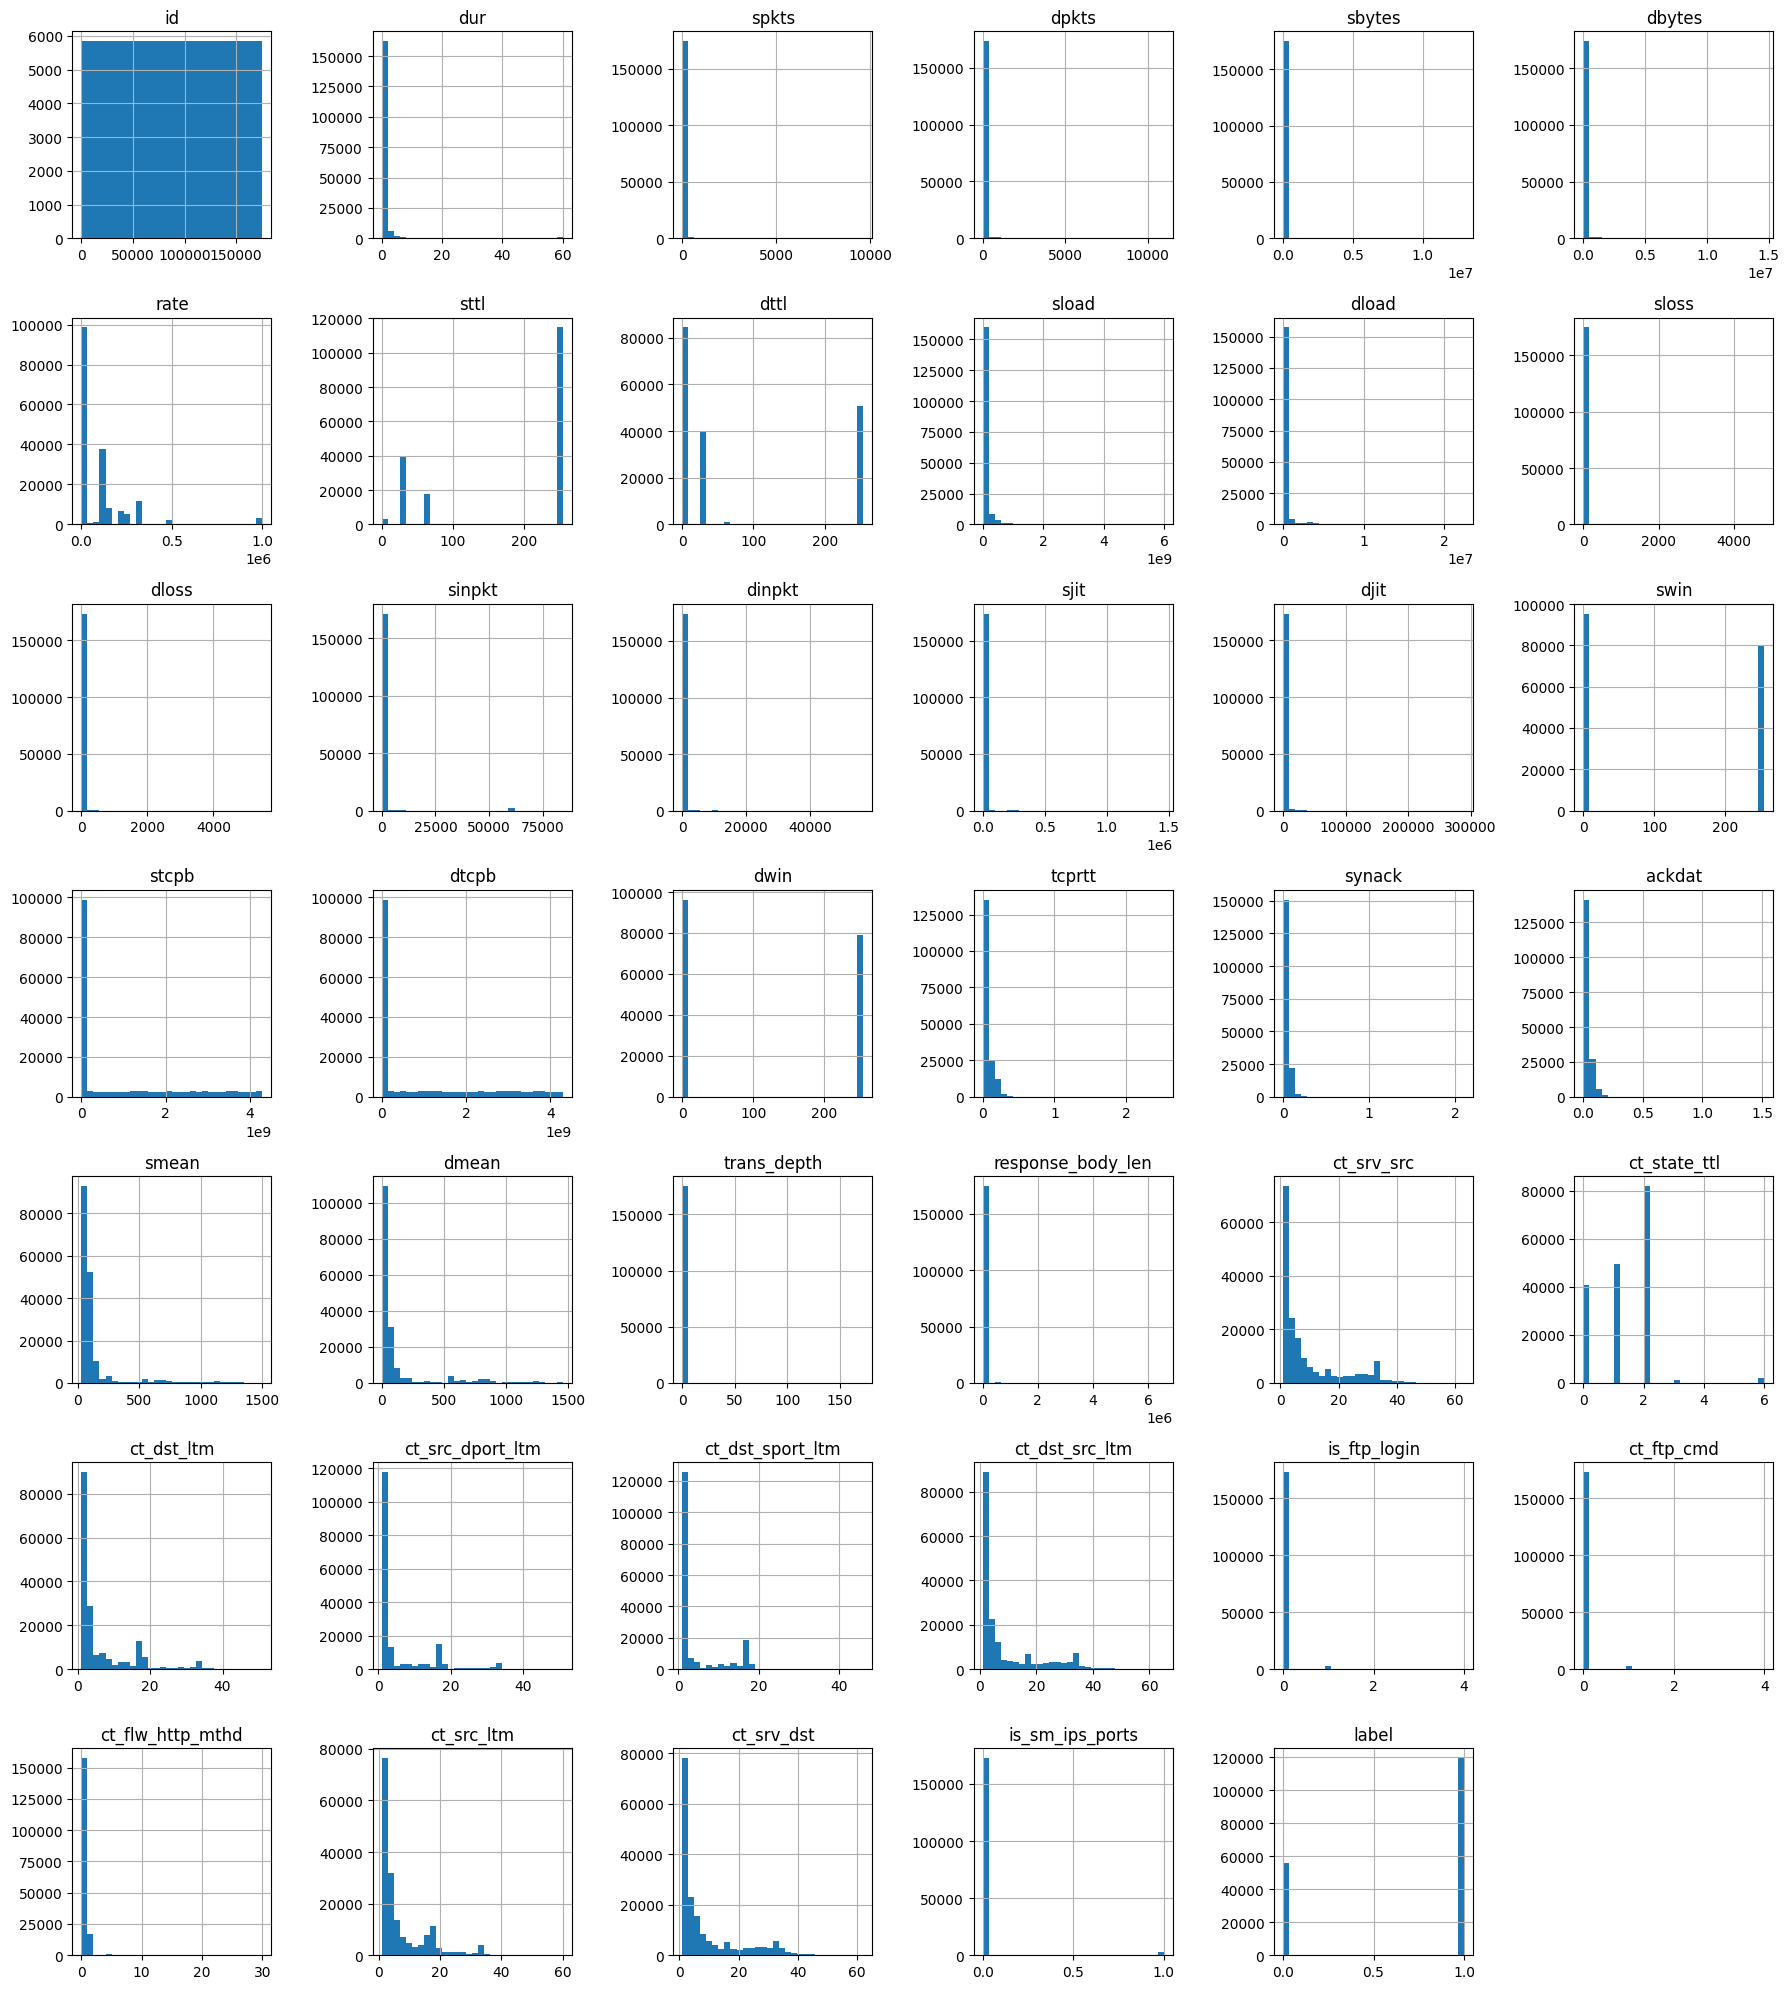

In [12]:
# Feature distributions: histograms

train_df[numerical_features].hist(
    figsize=(18, 20),
    bins=30
)

plt.tight_layout()
plt.show()

In [13]:
# Potential outliers: IQR method

Q1 = train_df[numerical_features].quantile(0.25)
Q3 = train_df[numerical_features].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    ((train_df[numerical_features] < lower_bound) |
     (train_df[numerical_features] > upper_bound))
    .sum()
    .sort_values(ascending=False)
)

print("POTENTIAL OUTLIERS BY FEATURE")

display(
    pd.DataFrame({
        "Potential Outliers": outlier_counts,
        "Percentage": (outlier_counts / len(train_df) * 100).round(2)
    })
)

POTENTIAL OUTLIERS BY FEATURE


,Potential Outliers,Percentage
dload,38143,21.75
ct_dst_sport_ltm,37337,21.29
ct_src_dport_ltm,33423,19.06
synack,31462,17.94
dloss,28388,16.19
dbytes,28131,16.04
spkts,24675,14.07
dmean,23359,13.32
sbytes,22873,13.04
ct_dst_ltm,22152,12.63


## 3.6 Data dictionary

The UNSW-NB15 dataset contains network traffic features describing the characteristics of individual network flows. The variables include numerical, categorical and binary attributes related to network protocols, packet and byte volumes, timing characteristics, TCP connection information and contextual connection counts.

The original UNSW-NB15 dataset documentation provides descriptions of the features used to characterize network traffic. The dictionary below focuses on the variables available in the training and testing datasets used in this project.

For numerical variables, the observed range is reported from the training dataset. For categorical and binary variables, the possible values observed in the dataset are reported instead.

In [14]:
# DATA DICTIONARY

variable_descriptions = {
    "id": "Unique identifier assigned to the network flow",
    "dur": "Duration of the network connection, measured in seconds",
    "proto": "Network protocol used by the connection",
    "service": "Network service associated with the connection",
    "state": "State of the network connection",
    "spkts": "Number of packets transmitted from the source",
    "dpkts": "Number of packets transmitted to the destination",
    "sbytes": "Total number of bytes transmitted from the source",
    "dbytes": "Total number of bytes transmitted to the destination",
    "rate": "Data transmission rate during the network flow",
    "sttl": "Time To Live (TTL) value observed from the source",
    "dttl": "Time To Live (TTL) value observed from the destination",
    "sload": "Amount of data transmitted per second from the source",
    "dload": "Amount of data transmitted per second to the destination",
    "sloss": "Number of packets lost from the source",
    "dloss": "Number of packets lost to the destination",
    "sinpkt": "Average time between packets transmitted from the source",
    "dinpkt": "Average time between packets transmitted to the destination",
    "sjit": "Variation in packet timing from the source (source jitter)",
    "djit": "Variation in packet timing at the destination (destination jitter)",
    "swin": "Source TCP window size",
    "stcpb": "Source TCP base sequence number",
    "dtcpb": "Destination TCP base sequence number",
    "dwin": "Destination TCP window size",
    "tcprtt": "TCP round-trip time between source and destination",
    "synack": "Time between the SYN and SYN-ACK packets",
    "ackdat": "Time between the SYN-ACK and ACK packets",
    "smean": "Mean packet size transmitted from the source",
    "dmean": "Mean packet size transmitted to the destination",
    "trans_depth": "Depth of the connection within an HTTP transaction",
    "response_body_len": "Length of the HTTP response body",
    "ct_srv_src": "Number of connections involving the same service and source in the relevant time window",
    "ct_state_ttl": "Number of connections sharing the same state and TTL characteristics",
    "ct_dst_ltm": "Number of connections involving the same destination in the relevant time window",
    "ct_src_dport_ltm": "Number of connections from the same source to the same destination port in the relevant time window",
    "ct_dst_sport_ltm": "Number of connections to the same destination from the same source port in the relevant time window",
    "ct_dst_src_ltm": "Number of connections between the same source and destination in the relevant time window",
    "is_ftp_login": "Indicator of whether an FTP login was performed",
    "ct_ftp_cmd": "Number of FTP commands associated with the connection",
    "ct_flw_http_mthd": "Number of HTTP methods associated with the connection",
    "ct_src_ltm": "Number of connections involving the same source in the relevant time window",
    "ct_srv_dst": "Number of connections involving the same service and destination",
    "is_sm_ips_ports": "Indicator of whether the source and destination IP addresses and ports are identical",
    "attack_cat": "Category of attack associated with the network flow",
    "label": "Indicates whether the network flow is normal (0) or malicious (1)"
}

# Create data dictionary
data_dictionary = []

for column in train_df.columns:

    dtype = train_df[column].dtype
    unique_count = train_df[column].nunique()

    # Categorical variables
    if train_df[column].dtype == "object":

        values = train_df[column].dropna().unique()

        if len(values) <= 15:
            observed_values = ", ".join(map(str, sorted(values)))
        else:
            examples = ", ".join(map(str, values[:8]))
            observed_values = f"{unique_count} observed values (e.g. {examples}, ...)"

    # Numerical variables
    else:
        min_value = train_df[column].min()
        max_value = train_df[column].max()

        observed_values = f"{min_value:g} – {max_value:g}"

    # Define variable role
    if column == "label":
        role = "Target variable"
    elif column == "id":
        role = "Identifier – excluded from modelling"
    elif column == "attack_cat":
        role = "Analysis variable – excluded from modelling"
    else:
        role = "Predictive feature"

    data_dictionary.append({
        "Variable": column,
        "Description / Meaning": variable_descriptions[column],
        "Data Type": str(dtype),
        "Unique Values": unique_count,
        "Observed Range / Values": observed_values,
        "Role": role
    })

data_dictionary_df = pd.DataFrame(data_dictionary)

display(data_dictionary_df)

,Variable,Description / Meaning,Data Type,Unique Values,Observed Range / Values,Role
0,id,Unique identifier assigned to the network flow,int64,175341,1 – 175341,Identifier – excluded from modelling
1,dur,"Duration of the network connection, measured i...",float64,74039,0 – 60,Predictive feature
2,proto,Network protocol used by the connection,object,133,"133 observed values (e.g. tcp, udp, arp, ospf,...",Predictive feature
3,service,Network service associated with the connection,object,13,"-, dhcp, dns, ftp, ftp-data, http, irc, pop3, ...",Predictive feature
4,state,State of the network connection,object,9,"CON, ECO, FIN, INT, PAR, REQ, RST, URN, no",Predictive feature
5,spkts,Number of packets transmitted from the source,int64,480,1 – 9616,Predictive feature
6,dpkts,Number of packets transmitted to the destination,int64,443,0 – 10974,Predictive feature
7,sbytes,Total number of bytes transmitted from the source,int64,7214,28 – 1.29652e+07,Predictive feature
8,dbytes,Total number of bytes transmitted to the desti...,int64,6660,0 – 1.46556e+07,Predictive feature
9,rate,Data transmission rate during the network flow,float64,76991,0 – 1e+06,Predictive feature


## 3.7 Key findings and implications for data preparation

The data understanding stage provided an initial assessment of the structure, quality, and characteristics of the UNSW-NB15 dataset. The main findings and their implications for the subsequent data preparation and modelling stages are summarized below.

- The dataset contains **257,673 network traffic observations** across the official training and testing sets, with **45 columns** in each dataset. The training set contains **175,341 observations**, while the testing set contains **82,332 observations**.

- The dataset combines **numerical and categorical variables** describing different characteristics of network traffic, including connection duration, packet and byte volumes, transmission rates, timing information, TCP characteristics, protocols, services, and connection states.

- The training dataset contains **30 integer variables, 11 floating-point variables, and 4 categorical variables**, meaning that different preprocessing strategies will be required depending on the type of feature.

- **No missing values were detected** in the training dataset. Therefore, no imputation strategy is required based on the initial data quality assessment.

- **No duplicate observations were identified** in the original training dataset. No duplicate removal is therefore required at this stage.

- The variables have substantially different numbers of unique values. In particular, `proto` contains **133 unique values**, while `service` contains **13** and `state` contains **9**. These categorical variables will therefore require appropriate encoding before being used by the machine learning models.

- `id` is a **unique identifier for each network flow**. It does not represent a meaningful behavioural characteristic of the traffic and will therefore be excluded from predictive modelling.

- `label` contains **two classes, 0 and 1**, confirming the binary classification problem defined in Step 1. In the training dataset, approximately **68% of observations are malicious and 32% are normal**, indicating a class imbalance that will need to be considered when evaluating model performance.

- `attack_cat` contains the **attack category associated with each traffic flow**. This variable will be retained for descriptive analysis and later error analysis, but will not be used as a predictive feature because it contains information directly related to the nature of the target and could introduce target leakage into the binary classification task.

- The numerical features show **substantially different scales and distributions**. Several variables are strongly right-skewed and display long-tailed distributions, indicating that observations are not evenly distributed across their observed ranges.

- The IQR analysis identifies **potential extreme observations across several numerical variables**. These observations will not be automatically removed because extreme network traffic characteristics may represent legitimate network behaviour or meaningful indicators of malicious activity rather than data errors.

- The analysis therefore indicates that the dataset is **complete with respect to missing values and duplicate rows**, but several preprocessing considerations remain necessary. These include categorical encoding, feature selection, appropriate feature scaling where required, investigation of skewed distributions, and careful assessment of potential extreme values.

The findings from this data understanding stage will guide the next stage of the project, which will focus on data preprocessing, exploratory data analysis, feature engineering, feature selection, and dimensionality reduction before model development.

# 4. Data preprocessing, EDA & feature engineering

## 4.1 Data preparation

The variables need to be clearly separated according to their role in the project:
- The `label` variable is defined as the target variable, while `id` is an identifier and does not contain predictive information about network traffic.
- The `attack_cat` variable provides information about the type of attack and will be retained for subsequent analysis, but excluded from the predictive features to avoid data leakage.
- The remaining variables will be considered as candidate predictive features and will be separated into numerical and categorical variables according to their data type.

In [15]:
# DEFINE TARGETS AND PREDICTIVE FEATURES

# Target variable
target = "label"

# Variables excluded from predictive modelling
excluded_features = ["id", "attack_cat"]

# Predictive features
feature_columns = [
    column for column in train_df.columns
    if column not in excluded_features + [target]
]

X = train_df[feature_columns].copy()
y = train_df[target].copy()

print("Number of predictive features:", len(feature_columns))
print("Target variable:", target)
print("Excluded variables:", excluded_features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Number of predictive features: 42
Target variable: label
Excluded variables: ['id', 'attack_cat']

X shape: (175341, 42)
y shape: (175341,)


In [16]:
# Check target distribution

print("TARGET DISTRIBUTION")

target_counts = y.value_counts().sort_index()
target_percentages = y.value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

display(target_summary)

TARGET DISTRIBUTION


,Count,Percentage
label,,
0,56000,31.94
1,119341,68.06


In [17]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("NUMBER OF NUMERICAL FEATURES:", len(numerical_features))
print("NUMBER OF CATEGORICAL FEATURES:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

NUMBER OF NUMERICAL FEATURES: 39
NUMBER OF CATEGORICAL FEATURES: 3

Categorical features:
['proto', 'service', 'state']

Numerical features:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


## 4.2 Exploratory Data Analysis (EDA)

The analysis focuses on the distribution of the target variable, the relationship between network traffic features and malicious activity, and the relationships between predictive variables.

The objective is to identify relevant patterns and potential issues that can inform subsequent preprocessing, feature engineering, feature selection, and model development decisions.

### 4.2.1 Target variable distribution

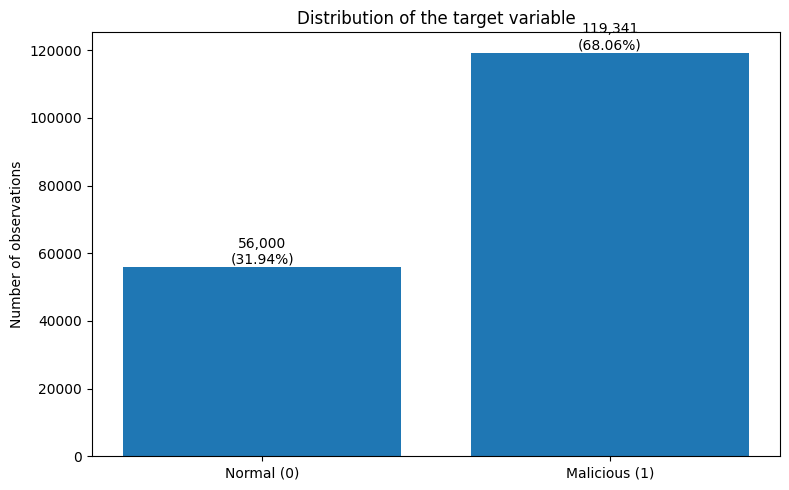

In [18]:
target_counts = y.value_counts().sort_index()
target_percentages = y.value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ["Normal (0)", "Malicious (1)"],
    target_counts.values
)

ax.set_title("Distribution of the target variable")
ax.set_ylabel("Number of observations")

# Add counts and percentages above bars
for bar, count, percentage in zip(
    bars,
    target_counts.values,
    target_percentages.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [19]:
# Target distribution summary

target_distribution = pd.DataFrame({
    "Class": ["Normal", "Malicious"],
    "Label": [0, 1],
    "Count": [
        target_counts[0],
        target_counts[1]
    ],
    "Percentage": [
        round(target_percentages[0], 2),
        round(target_percentages[1], 2)
    ]
})

display(target_distribution)

,Class,Label,Count,Percentage
0,Normal,0,56000,31.94
1,Malicious,1,119341,68.06


**Interpretation**

The target variable is moderately imbalanced, with malicious traffic representing **68.06%** of the training observations and normal traffic representing **31.94%**.

This imbalance is not severe enough to make the dataset unsuitable for classification, but it should be taken into account during model development and evaluation. Accuracy alone may not adequately reflect the model's ability to detect malicious traffic and limit false alerts.

Therefore, model performance will be assessed using multiple complementary metrics, with particular attention to **Recall, Precision, F1-score, PR-AUC, and False Positive Rate**.

### 4.2.2 Numerical features and target relationship

This next step examines whether the numerical network traffic features differ between normal and malicious observations.

Comparing the distributions of numerical features across the two target classes can help identify variables that may contain useful information for distinguishing malicious traffic from normal traffic.

This analysis is exploratory and does not by itself determine which features will be retained for modelling. The results will instead be used to identify relevant patterns and guide the subsequent feature engineering and feature selection stages.

In [20]:
numerical_features_no_target = [
    feature for feature in numerical_features
    if feature != "label"
]

# Calculate median for each numerical feature by target class
median_by_class = train_df.groupby("label")[numerical_features_no_target].median().T

# Rename columns for readability
median_by_class.columns = ["Normal (0)", "Malicious (1)"]

display(median_by_class)

,Normal (0),Malicious (1)
dur,3.860250e-02,9.000000e-06
spkts,1.200000e+01,2.000000e+00
dpkts,1.000000e+01,0.000000e+00
sbytes,1.470000e+03,2.000000e+02
dbytes,1.112000e+03,0.000000e+00
rate,1.382257e+03,1.111111e+05
sttl,3.100000e+01,2.540000e+02
dttl,2.900000e+01,0.000000e+00
sload,4.313277e+05,5.066666e+07
dload,3.361206e+05,0.000000e+00


In [21]:
feature_comparison = pd.DataFrame({
    "Normal Median": train_df[train_df["label"] == 0][numerical_features_no_target].median(),
    "Malicious Median": train_df[train_df["label"] == 1][numerical_features_no_target].median()
})

feature_comparison["Absolute Difference"] = (
    feature_comparison["Malicious Median"] -
    feature_comparison["Normal Median"]
).abs()

feature_comparison = feature_comparison.sort_values(
    "Absolute Difference",
    ascending=False
)

display(feature_comparison)

,Normal Median,Malicious Median,Absolute Difference
stcpb,1.180207e+09,0.000000e+00,1.180207e+09
dtcpb,1.152046e+09,0.000000e+00,1.152046e+09
sload,4.313277e+05,5.066666e+07,5.023534e+07
dload,3.361206e+05,0.000000e+00,3.361206e+05
rate,1.382257e+03,1.111111e+05,1.097289e+05
sbytes,1.470000e+03,2.000000e+02,1.270000e+03
dbytes,1.112000e+03,0.000000e+00,1.112000e+03
dwin,2.550000e+02,0.000000e+00,2.550000e+02
swin,2.550000e+02,0.000000e+00,2.550000e+02
sttl,3.100000e+01,2.540000e+02,2.230000e+02


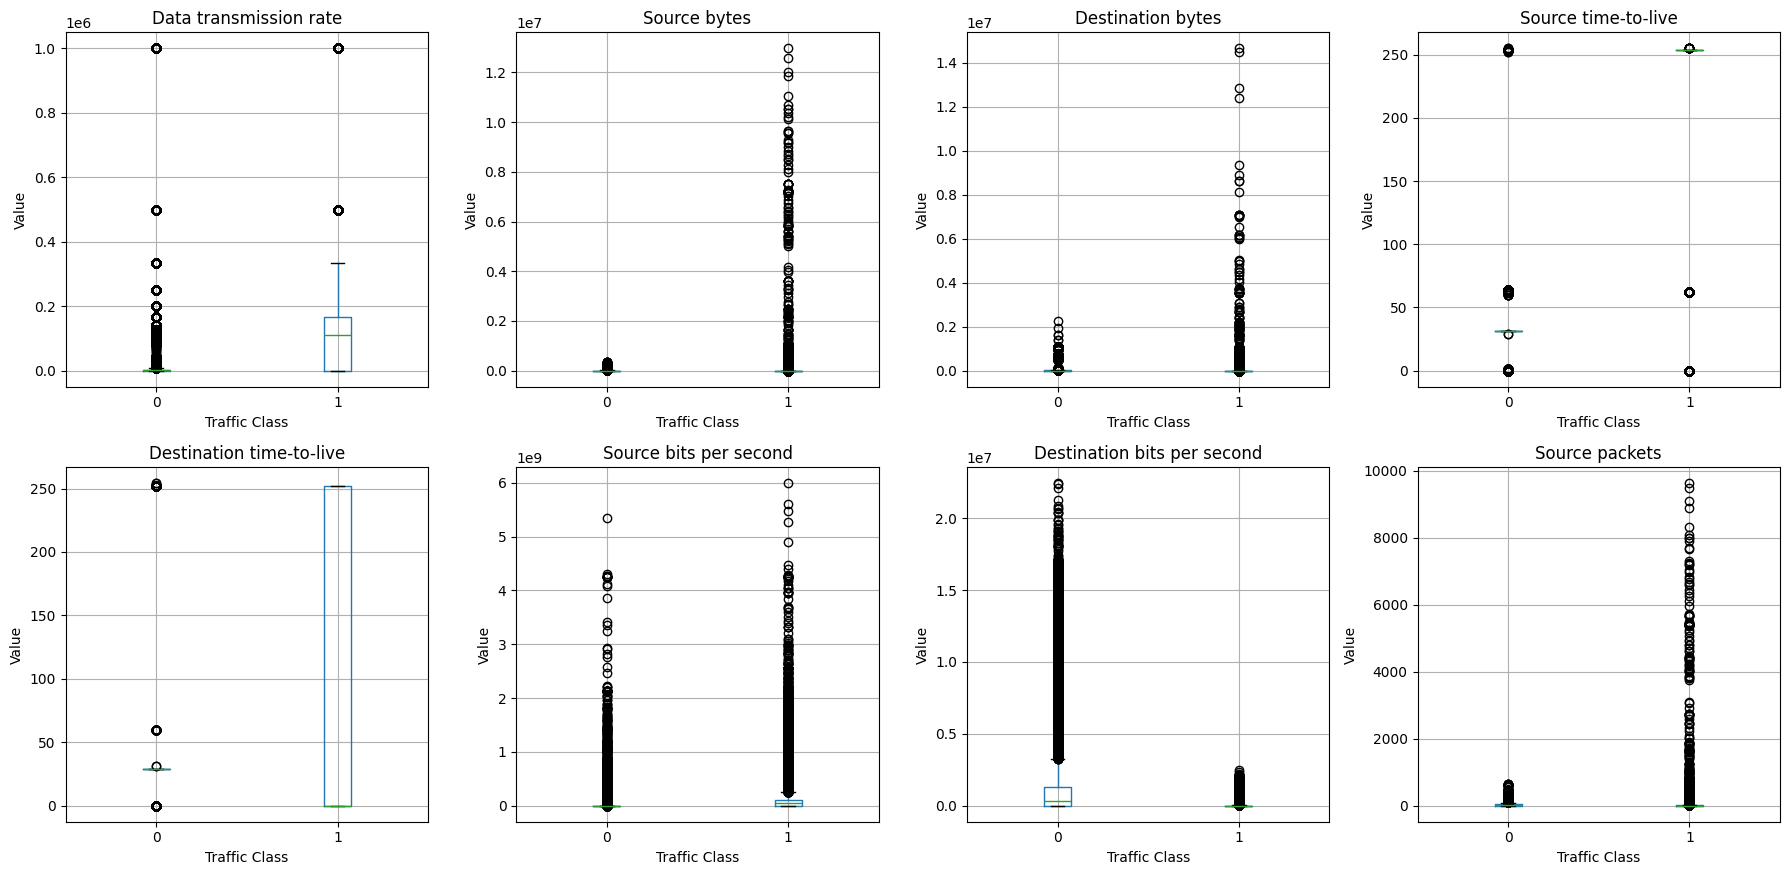

In [22]:
# Visual comparison of selected numerical features

selected_features = [
    "rate",
    "sbytes",
    "dbytes",
    "sttl",
    "dttl",
    "sload",
    "dload",
    "spkts"
]

feature_labels = {
    "rate": "Data transmission rate",
    "sbytes": "Source bytes",
    "dbytes": "Destination bytes",
    "sttl": "Source time-to-live",
    "dttl": "Destination time-to-live",
    "sload": "Source bits per second",
    "dload": "Destination bits per second",
    "spkts": "Source packets"
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, feature in zip(axes.flatten(), selected_features):
    train_df.boxplot(
        column=feature,
        by="label",
        ax=ax
    )

    ax.set_title(feature_labels[feature])
    ax.set_xlabel("Traffic Class")
    ax.set_ylabel("Value")

plt.suptitle("")
plt.tight_layout()
plt.show()

**Interpretation**

The boxplots show visible differences in the distributions of several numerical features between normal and malicious traffic, including data transmission rate, source and destination bytes, source and destination time-to-live values, source and destination load, and source packet counts.

These differences suggest that some network traffic characteristics may contain useful information for distinguishing between normal and malicious traffic. However, the visual comparison alone is not sufficient to determine feature importance. Feature selection and model-based analysis will therefore be used later to identify the most informative predictive features.

### 4.2.3 Categorical features and target relationship

The categorical features `proto`, `service`, and `state` describe different characteristics of network communications.

The analysis examines how the target variable is distributed across these categories in order to identify whether particular protocols, services, or connection states are more frequently associated with malicious traffic.

Because `proto` contains a relatively large number of unique values, the analysis focuses on the most frequently observed categories rather than displaying all categories simultaneously. The proportion of malicious traffic within each category is also examined to distinguish between category frequency and association with malicious activity.

These analyses are exploratory and will not be used alone to determine feature importance.

The `proto` variable identifies the network protocol used by each connection. Examining the distribution of normal and malicious traffic across protocols can help identify whether certain communication protocols are more frequently associated with malicious activity in the dataset.


In [23]:
protocol_analysis = (
    train_df.groupby("proto")
    .agg(
        Total_Flows=("label", "count"),
        Malicious_Flows=("label", "sum"),
        Malicious_Rate=("label", "mean")
    )
    .sort_values("Total_Flows", ascending=False)
)

protocol_analysis["Malicious_Rate"] = (
    protocol_analysis["Malicious_Rate"] * 100
).round(2)

display(protocol_analysis.head(15))

,Total_Flows,Malicious_Flows,Malicious_Rate
proto,,,
tcp,79946,40825,51.07
udp,63283,49361,78.00
unas,12084,12084,100.00
arp,2859,0,0.00
ospf,2595,2531,97.53
sctp,1150,1150,100.00
any,300,300,100.00
gre,225,225,100.00
swipe,201,201,100.00


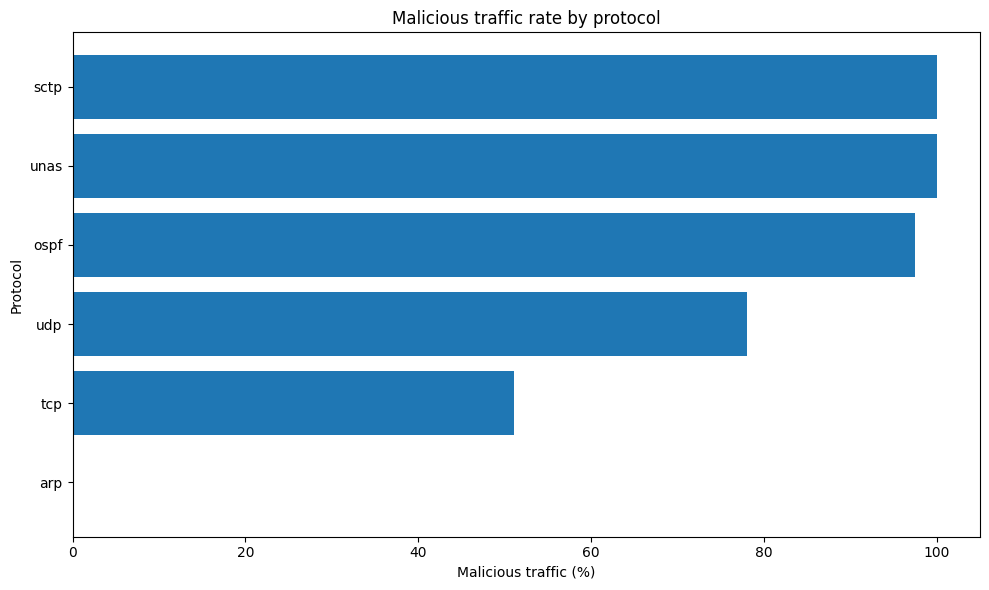

In [24]:
# Protocols with sufficient observations

protocol_plot = protocol_analysis[
    protocol_analysis["Total_Flows"] >= 1000
].sort_values(
    "Malicious_Rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    protocol_plot.index,
    protocol_plot["Malicious_Rate"]
)

plt.xlabel("Malicious traffic (%)")
plt.ylabel("Protocol")
plt.title("Malicious traffic rate by protocol")

plt.tight_layout()
plt.show()

#### 4.2.3.2 Service and target relationship

The `service` variable identifies the network service associated with a connection. Since services may be exposed to different types of network activity, their distribution across normal and malicious traffic can provide additional information about the dataset.

In [25]:
service_analysis = (
    train_df.groupby("service")
    .agg(
        Total_Flows=("label", "count"),
        Malicious_Flows=("label", "sum"),
        Malicious_Rate=("label", "mean")
    )
    .sort_values("Total_Flows", ascending=False)
)

service_analysis["Malicious_Rate"] = (
    service_analysis["Malicious_Rate"] * 100
).round(2)

display(service_analysis)

,Total_Flows,Malicious_Flows,Malicious_Rate
service,,,
-,94168,57656,61.23
dns,47294,39801,84.16
http,18724,13376,71.44
smtp,5058,3479,68.78
ftp-data,3995,1443,36.12
ftp,3428,2210,64.47
ssh,1302,11,0.84
pop3,1105,1101,99.64
dhcp,94,94,100.00


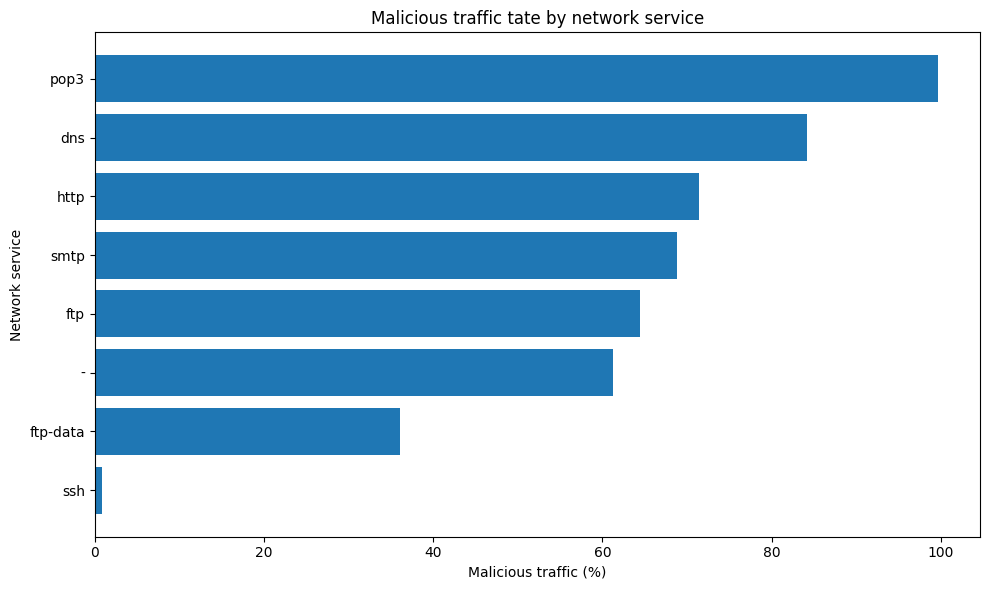

In [26]:
# Services with sufficient observations

service_plot = service_analysis[
    service_analysis["Total_Flows"] >= 500
].sort_values(
    "Malicious_Rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    service_plot.index,
    service_plot["Malicious_Rate"]
)

plt.xlabel("Malicious traffic (%)")
plt.ylabel("Network service")
plt.title("Malicious traffic tate by network service")

plt.tight_layout()
plt.show()

#### 4.2.3.3 Connection State and Target relationship

The `state` variable describes the state of the network connection. Examining its relationship with the target can indicate whether certain connection states occur more frequently in malicious traffic.

In [27]:
state_analysis = (
    train_df.groupby("state")
    .agg(
        Total_Flows=("label", "count"),
        Malicious_Flows=("label", "sum"),
        Malicious_Rate=("label", "mean")
    )
    .sort_values("Total_Flows", ascending=False)
)

state_analysis["Malicious_Rate"] = (
    state_analysis["Malicious_Rate"] * 100
).round(2)

display(state_analysis)

,Total_Flows,Malicious_Flows,Malicious_Rate
state,,,
INT,82275,76560,93.05
FIN,77825,40650,52.23
CON,13152,1053,8.01
REQ,1991,1066,53.54
RST,83,12,14.46
ECO,12,0,0.00
PAR,1,0,0.00
URN,1,0,0.00
no,1,0,0.00


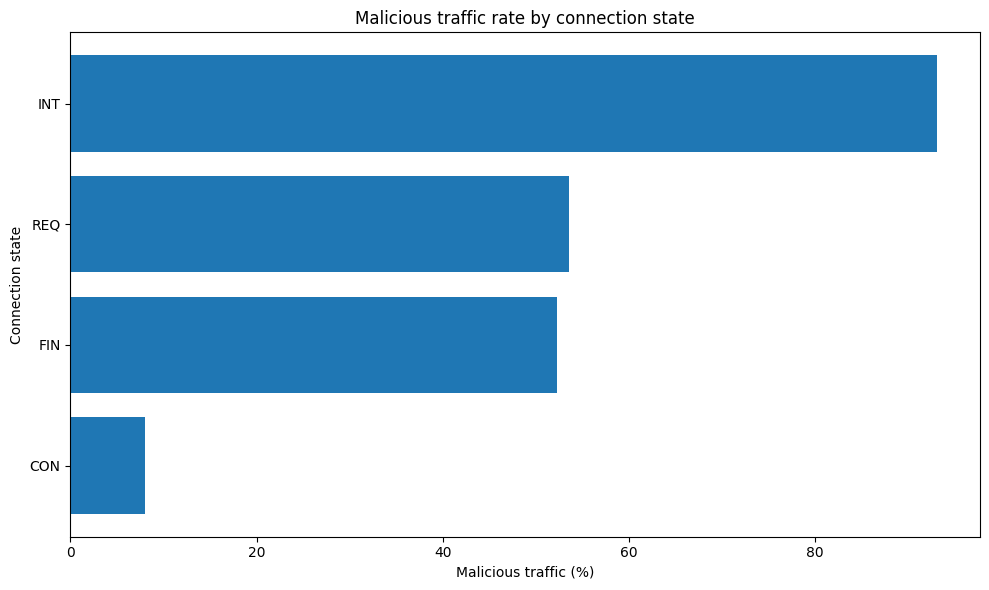

In [28]:
# CONNECTION states with sufficient observations

state_plot = state_analysis[
    state_analysis["Total_Flows"] >= 500
].sort_values(
    "Malicious_Rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    state_plot.index,
    state_plot["Malicious_Rate"]
)

plt.xlabel("Malicious traffic (%)")
plt.ylabel("Connection state")
plt.title("Malicious traffic rate by connection state")

plt.tight_layout()
plt.show()

#### 4.2.3.4 Categorical EDA findings

The categorical analysis reveals substantial differences in the proportion of malicious traffic across network protocols, network services, and connection states.

A **network protocol** defines how devices communicate over a network. In the dataset, TCP (Transmission Control Protocol) is one of the main protocols and is designed to establish a connection and provide reliable data transmission, while UDP (User Datagram Protocol) is connectionless and generally involves less communication overhead.

Malicious traffic represents approximately 51% of TCP flows and 78% of UDP flows in the training dataset. Several other sufficiently represented protocols show even higher malicious traffic rates, while ARP traffic is predominantly associated with the normal class in this dataset.

The **service variable** identifies the network service associated with a connection, such as DNS, HTTP, FTP, SMTP, or SSH. The analysis also shows substantial differences between these services. DNS, HTTP, SMTP, FTP, and POP3 present relatively high proportions of malicious traffic, whereas SSH shows a much lower proportion of malicious observations.

The **state variable** describes the state of a network connection. For example, CON corresponds to an established connection, whereas INT corresponds to an interrupted connection. The analysis shows particularly strong differences between connection states: the INT state is associated with a very high proportion of malicious traffic (93.05%), while the CON state has a substantially lower malicious rate (8.01%).

These results suggest that protocol, service, and connection-state characteristics may provide useful information for distinguishing normal and malicious network traffic. However, these percentages describe associations observed in the UNSW-NB15 dataset and should not be interpreted as causal relationships or as definitive indicators of malicious activity.

Categories with very few observations were also not emphasized in the visual analysis because their percentages can be unstable.

These findings will inform the subsequent feature selection and model development stages, where the predictive value of these variables will be assessed more rigorously.

### 4.2.4 Correlation analysis

Correlation analysis is used to examine the relationships between numerical features in the dataset.

A correlation measures the strength and direction of the relationship between two numerical variables. A positive correlation means that the two variables tend to increase together, while a negative correlation means that one variable tends to increase when the other decreases. A correlation close to zero indicates that there is little linear relationship between the two variables.

This analysis is useful for identifying groups of features that may contain similar information. Highly correlated variables may indicate redundancy and may therefore be considered during the subsequent feature selection stage.

The correlation analysis does not imply causation. It is used here as an exploratory tool to better understand the structure of the dataset and to inform subsequent feature selection and model development.

4.2.4.1 Correlation matrix

In [29]:
# Select numerical predictive features
numerical_features_for_corr = X.select_dtypes(include=np.number).columns.tolist()

# Calculate Pearson correlation matrix
correlation_matrix = train_df[numerical_features_for_corr].corr()

# Display correlation matrix
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

display(correlation_matrix.round(2))

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
dur,1.00,0.25,0.18,0.20,0.14,-0.12,0.01,0.04,-0.08,-0.05,0.20,0.14,0.08,0.15,0.14,0.16,0.02,0.01,0.01,0.02,0.05,0.05,0.05,0.09,0.03,0.00,0.08,-0.11,0.19,-0.09,-0.09,-0.09,-0.10,0.02,0.02,0.02,-0.08,-0.12,0.04
spkts,0.25,1.00,0.39,0.96,0.21,-0.08,-0.10,0.07,-0.05,0.08,0.97,0.21,-0.02,-0.00,-0.00,0.02,0.13,0.11,0.10,0.13,0.04,0.04,0.04,0.22,0.15,0.01,0.09,-0.07,-0.09,-0.06,-0.07,-0.07,-0.08,0.01,0.01,0.01,-0.06,-0.07,-0.02
dpkts,0.18,0.39,1.00,0.19,0.97,-0.10,-0.19,0.05,-0.07,0.14,0.20,0.98,-0.02,-0.01,0.00,0.05,0.18,0.14,0.14,0.19,0.02,0.02,0.02,0.01,0.44,0.03,0.44,-0.08,-0.15,-0.07,-0.09,-0.09,-0.09,0.01,0.01,0.05,-0.08,-0.08,-0.02
sbytes,0.20,0.96,0.19,1.00,0.01,-0.03,-0.02,0.06,-0.02,-0.01,1.00,0.01,-0.01,0.00,-0.00,-0.00,0.05,0.04,0.04,0.05,0.04,0.04,0.04,0.23,-0.00,0.00,0.00,-0.03,-0.01,-0.03,-0.03,-0.03,-0.03,-0.00,-0.00,-0.00,-0.03,-0.03,-0.01
dbytes,0.14,0.21,0.97,0.01,1.00,-0.06,-0.14,0.02,-0.04,0.10,0.02,1.00,-0.01,-0.01,-0.00,0.05,0.11,0.09,0.09,0.11,0.00,0.00,0.01,-0.04,0.42,0.03,0.47,-0.05,-0.09,-0.04,-0.05,-0.06,-0.05,-0.01,-0.01,0.05,-0.05,-0.04,-0.01
rate,-0.12,-0.08,-0.10,-0.03,-0.06,1.00,0.41,-0.41,0.60,-0.15,-0.04,-0.08,-0.08,-0.05,-0.06,-0.09,-0.52,-0.41,-0.41,-0.52,-0.30,-0.28,-0.29,-0.11,-0.27,-0.08,-0.02,0.36,0.43,0.32,0.35,0.39,0.38,-0.07,-0.07,-0.11,0.31,0.36,-0.07
sttl,0.01,-0.10,-0.19,-0.02,-0.14,0.41,1.00,-0.03,0.28,-0.40,-0.04,-0.16,-0.21,-0.00,0.02,-0.12,-0.42,-0.34,-0.33,-0.42,0.04,0.04,0.03,-0.01,-0.55,-0.06,-0.05,0.35,0.67,0.27,0.34,0.38,0.40,-0.12,-0.12,-0.11,0.27,0.34,-0.22
dttl,0.04,0.07,0.05,0.06,0.02,-0.41,-0.03,1.00,-0.28,-0.12,0.08,0.04,-0.08,0.10,0.15,0.10,0.75,0.59,0.60,0.75,0.81,0.75,0.78,0.19,0.14,0.15,0.02,-0.42,-0.26,-0.38,-0.37,-0.39,-0.40,0.11,0.11,0.22,-0.37,-0.43,-0.09
sload,-0.08,-0.05,-0.07,-0.02,-0.04,0.60,0.28,-0.28,1.00,-0.11,-0.03,-0.05,-0.05,-0.03,-0.04,-0.06,-0.35,-0.28,-0.28,-0.35,-0.20,-0.19,-0.20,0.22,-0.19,-0.05,-0.02,0.14,0.29,0.08,0.10,0.08,0.16,-0.05,-0.05,-0.07,0.08,0.14,-0.05
dload,-0.05,0.08,0.14,-0.01,0.10,-0.15,-0.40,-0.12,-0.11,1.00,0.01,0.12,-0.04,-0.02,-0.03,-0.03,0.27,0.22,0.21,0.27,-0.14,-0.13,-0.13,-0.08,0.55,-0.03,0.02,-0.08,-0.37,-0.10,-0.14,-0.15,-0.16,-0.03,-0.03,-0.04,-0.10,-0.09,-0.04


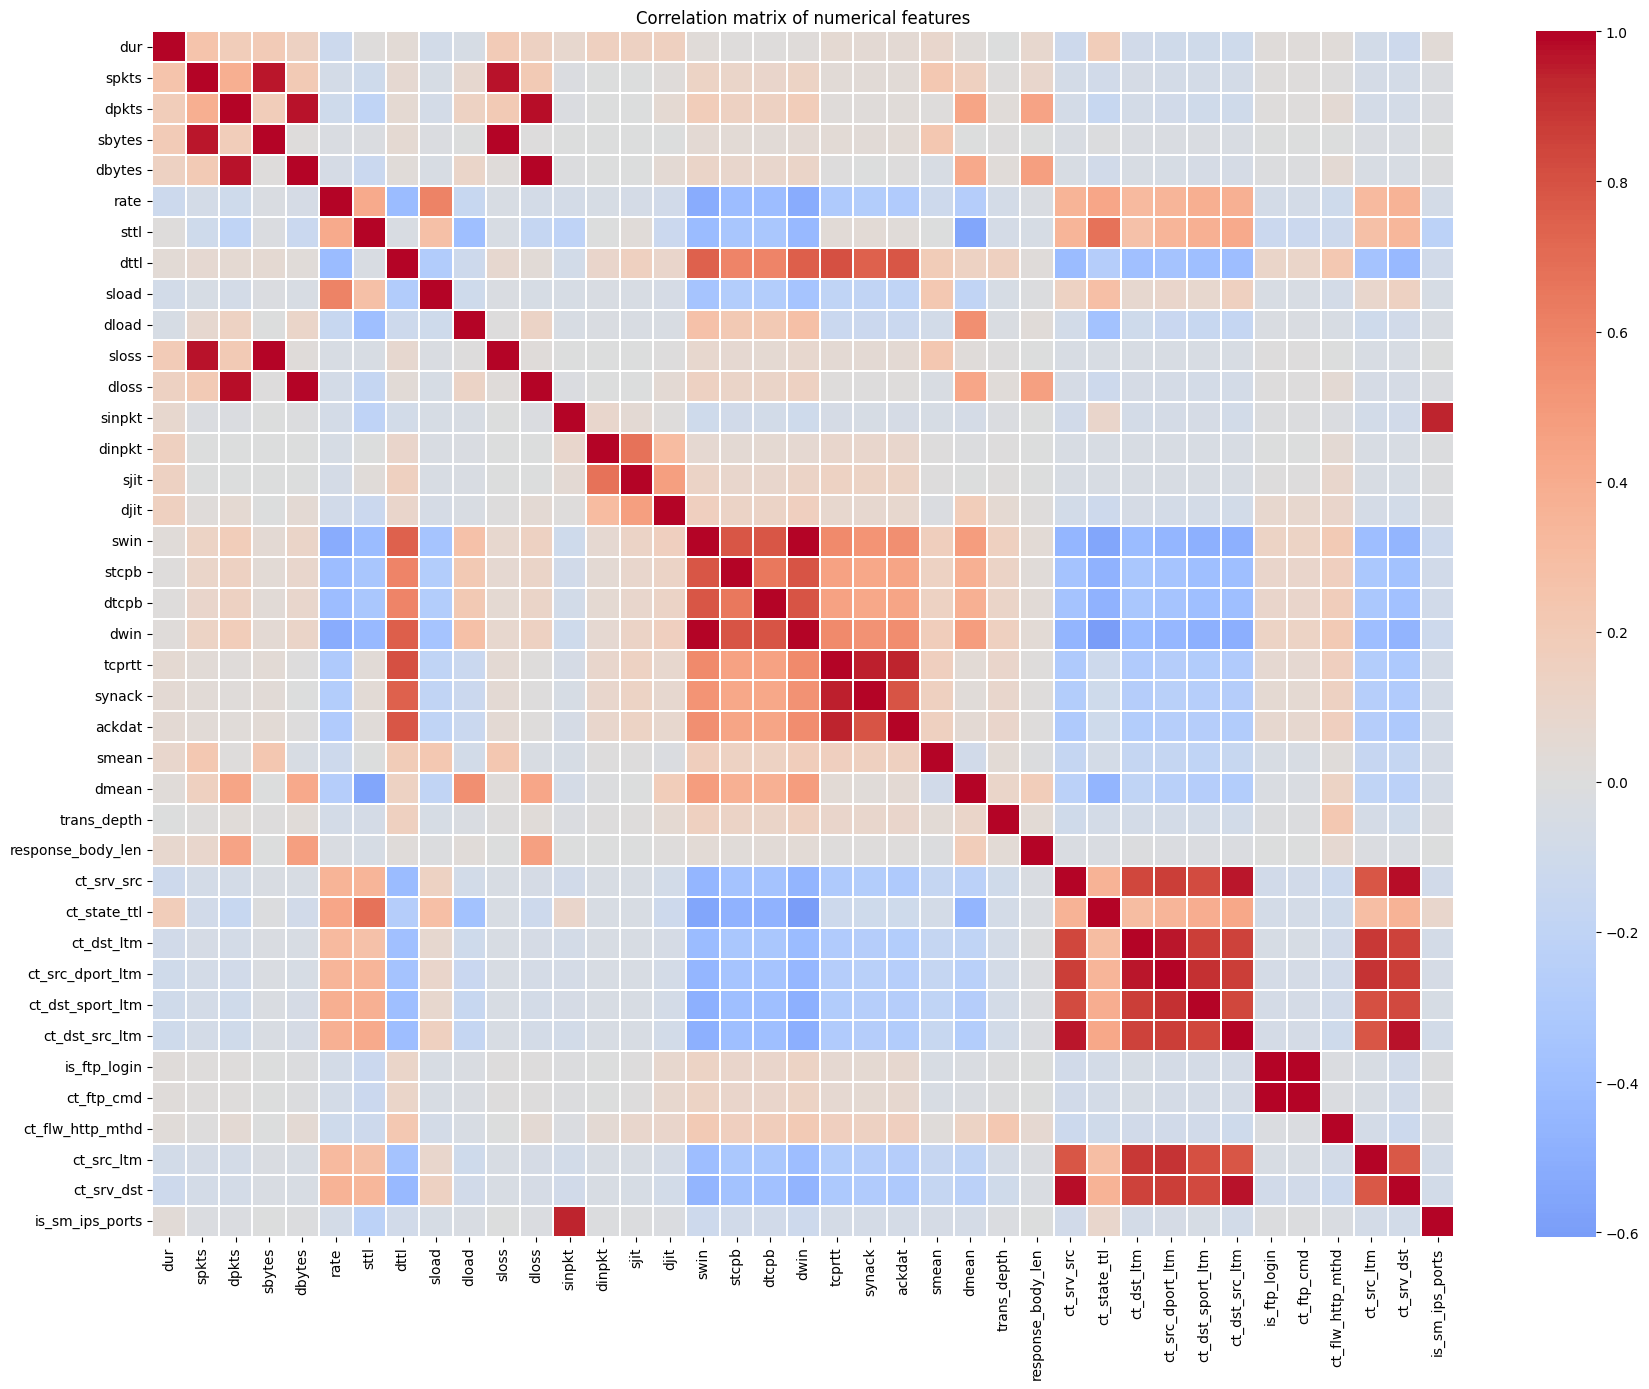

In [30]:
# Correlation heatmap

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation matrix of numerical features")
plt.tight_layout()
plt.show()

In [31]:
# STRONGEST FEATURE CORRELATIONS

# Keep only the upper triangle to avoid duplicate pairs
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Extract correlation pairs
strong_correlations = (
    upper_triangle
    .stack()
    .reset_index()
)

strong_correlations.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

# Keep strong absolute correlations
strong_correlations["Absolute Correlation"] = (
    strong_correlations["Correlation"].abs()
)

strong_correlations = (
    strong_correlations
    .sort_values("Absolute Correlation", ascending=False)
)

display(
    strong_correlations[
        strong_correlations["Absolute Correlation"] >= 0.70
    ].head(20)
)

,Feature 1,Feature 2,Correlation,Absolute Correlation
726,is_ftp_login,ct_ftp_cmd,1.000000,1.000000
152,dbytes,dloss,0.996504,0.996504
117,sbytes,sloss,0.996109,0.996109
490,swin,dwin,0.990140,0.990140
684,ct_srv_src,ct_srv_dst,0.980323,0.980323
83,dpkts,dloss,0.978636,0.978636
724,ct_dst_src_ltm,ct_srv_dst,0.972370,0.972370
76,dpkts,dbytes,0.971907,0.971907
46,spkts,sloss,0.971069,0.971069
679,ct_srv_src,ct_dst_src_ltm,0.967138,0.967138


In [32]:
# Highly correlated feature pairs

correlation_threshold = 0.90

high_corr_pairs = strong_correlations[
    strong_correlations["Absolute Correlation"] >= correlation_threshold
].copy()

high_corr_pairs = high_corr_pairs[
    ["Feature 1", "Feature 2", "Correlation"]
]

display(high_corr_pairs)

,Feature 1,Feature 2,Correlation
726,is_ftp_login,ct_ftp_cmd,1.000000
152,dbytes,dloss,0.996504
117,sbytes,sloss,0.996109
490,swin,dwin,0.990140
684,ct_srv_src,ct_srv_dst,0.980323
83,dpkts,dloss,0.978636
724,ct_dst_src_ltm,ct_srv_dst,0.972370
76,dpkts,dbytes,0.971907
46,spkts,sloss,0.971069
679,ct_srv_src,ct_dst_src_ltm,0.967138


#### 4.2.4.2 Interpretation of correlation analysis

The correlation analysis identifies several groups of numerical features that are strongly correlated with each other.

The strongest relationship is observed between the **FTP login indicator** and the **number of FTP commands**, with a correlation of **1.00**. These two variables are related to the same type of FTP activity: a successful FTP login generally enables subsequent FTP commands to be performed. The perfect correlation observed in this dataset therefore suggests that the two variables may capture very similar information. However, such a perfect relationship is not necessarily implied by their definitions alone and will therefore be considered during the subsequent feature selection stage.

Very strong correlations are also observed between variables describing **traffic volume and packet loss**. The **number of bytes transmitted from the source** is strongly correlated with the **number of packets lost at the source** (**0.996**), while the **number of bytes transmitted to the destination** is strongly correlated with the **number of packets lost at the destination** (**0.997**). Similarly, the **number of packets transmitted to the destination** is strongly correlated with the **number of packets lost at the destination** (**0.979**).

These relationships are broadly consistent with the characteristics of network traffic. Packet loss is measured in relation to packets exchanged during a flow, while the number of bytes reflects the amount of data carried by those packets. Consequently, variables describing the volume of packets, the volume of bytes, and packet loss can naturally evolve together within the same network flow. The strong correlation between the **number of packets transmitted from the source** and the **number of bytes transmitted from the source** (**0.964**) is particularly intuitive, since a larger number of packets will generally correspond to a larger volume of transmitted data.

Another group of strong correlations concerns **TCP connection timing characteristics**. The **TCP round-trip time** is strongly correlated with the **time between the SYN and SYN-ACK packets** (**0.949**) and with the **time between the SYN-ACK and ACK packets** (**0.942**). This is consistent with the fact that these variables describe closely related timing components of the same TCP connection process. It is therefore expected that they may vary together across network flows.

Finally, several variables measuring **connection counts within different time windows or according to different connection criteria** also show strong positive correlations. This is logically consistent because these variables measure related aspects of connection activity and may rely on overlapping network events. They can therefore provide partially redundant information about the same underlying traffic behaviour.

These results indicate that some predictive features may contain redundant or overlapping information. However, correlation alone is not sufficient to determine whether a feature should be removed, as a correlated variable may still provide useful information to a machine learning model.

The correlation analysis will therefore be used as one input to the subsequent feature selection stage, where the predictive contribution of the variables will be assessed using a dedicated feature selection method.

## 4.3 Data preprocessing

### 4.3.1 Preprocessing strategy

The exploratory analysis identified several characteristics that need to be considered before training the machine learning models.

First, the dataset contains no missing values and no exact duplicate observations in the original training data, so no imputation or duplicate removal is required.

The predictive variables include both numerical and categorical features. The categorical variables `proto`, `service`, and `state` therefore need to be converted into a numerical representation before they can be used by the machine learning algorithms.

The numerical variables have very different scales and distributions. Several features also exhibit strong skewness and extreme observations. These observations will not be removed automatically because, in a network intrusion detection context, extreme traffic characteristics may represent legitimate network behaviour or genuine malicious activity rather than data errors.

Numerical feature scaling will be applied selectively according to the requirements of each model. Standardization is appropriate for scale-sensitive models such as Logistic Regression, whereas tree-based models do not require numerical standardization.

The variables `id` and `attack_cat` have already been excluded from the predictive feature set. The `id` variable is an identifier rather than a behavioural characteristic, while `attack_cat` contains information about the attack category and could introduce target leakage into the binary classification task.

The preprocessing strategy will therefore focus on categorical encoding, model-appropriate numerical scaling, preservation of potentially meaningful extreme values, and prevention of data leakage.

### 4.3.2 Data cleaning

The data cleaning stage applies the data quality checks identified during the initial data understanding stage.

Missing values and duplicate observations are first verified on the data used for modelling. Additional analysis is then performed to assess repeated values across the predictive variables.

The results of these checks are used to determine whether any data-cleaning action is required before the subsequent preprocessing steps.

In [33]:
# Verifying missing values and repeated predictive patterns

print("Total missing values:", X.isnull().sum().sum())
print("Observations with repeated predictive patterns:", X.duplicated().sum())

Total missing values: 0
Observations with repeated predictive patterns: 74301


In [34]:
# Investigate duplicate predictive patterns


duplicate_features = train_df[
    train_df[feature_columns].duplicated(keep=False)
].copy()

label_consistency = (
    duplicate_features
    .groupby(feature_columns, dropna=False)["label"]
    .nunique()
)

print(
    "Number of duplicated predictive patterns:",
    duplicate_features[feature_columns].drop_duplicates().shape[0]
)

print(
    "Patterns associated with more than one label:",
    (label_consistency > 1).sum()
)

print(
    "Patterns associated with only one label:",
    (label_consistency == 1).sum()
)

Number of duplicated predictive patterns: 9748
Patterns associated with more than one label: 229
Patterns associated with only one label: 9519


In [35]:
# Size of ambiguous predictive patterns

ambiguous_patterns = label_consistency[label_consistency > 1]

ambiguous_rows = duplicate_features[
    duplicate_features[feature_columns]
    .apply(tuple, axis=1)
    .isin(ambiguous_patterns.index)
]

print("Ambiguous predictive patterns:", len(ambiguous_patterns))
print("Observations affected:", len(ambiguous_rows))

Ambiguous predictive patterns: 229
Observations affected: 940


The analysis identified no missing values and no exact duplicate rows in the original dataset. However, repeated predictive patterns were identified after excluding the identifier, target, and analysis-only variables.

Most repeated patterns are associated with a single target class, while 940 observations belong to patterns associated with both normal and malicious traffic. These observations are retained because repeated network traffic characteristics can legitimately occur across multiple network flows, and the proportion of ambiguous patterns is limited.

### 4.3.3 Handling categorical variables

The categorical features `proto`, `service`, and `state` are transformed using One-Hot Encoding. This converts each category into a binary variable without introducing an artificial numerical order between categories.

Unknown categories are ignored when applying the transformation to new data.

In [36]:
# Categorical encoding

categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

categorical_encoder.fit(X[categorical_features])

encoded_categories = categorical_encoder.transform(
    X[categorical_features]
)

print("Original categorical features:", categorical_features)
print("Number of encoded categorical features:", encoded_categories.shape[1])

Original categorical features: ['proto', 'service', 'state']
Number of encoded categorical features: 155


### 4.3.4 Numerical feature scaling

The numerical variables have substantially different scales and distributions. Standardization is therefore applied to the numerical features for scale-sensitive models such as Logistic Regression.

Tree-based models such as Decision Tree, Random Forest, and XGBoost do not require numerical standardization because their splitting mechanisms are not sensitive to differences in feature scale.

Scaling is therefore applied selectively within the modelling pipelines according to the requirements of each algorithm.

In [37]:
# Numerical feature scaling

scaler = StandardScaler()

scaler.fit(X[numerical_features])

scaled_numerical_features = scaler.transform(
    X[numerical_features]
)

print("Number of numerical features:", len(numerical_features))
print("Scaled data shape:", scaled_numerical_features.shape)

Number of numerical features: 39
Scaled data shape: (175341, 39)


### 4.3.5 Outlier treatment

The outlier analysis identified a number of extreme observations in several numerical features.

These observations will not be removed automatically. In network traffic data, extreme values may represent genuine traffic behaviour, including potentially malicious activity, rather than data errors.

The impact of these observations will instead be considered during model evaluation and feature selection.

### 4.3.6 Train/Test preprocessing pipeline

The preprocessing steps are incorporated into the modelling pipelines so that the transformations required by each model are learned from the available training data and then applied to validation or testing data.

During cross-validation, a fresh copy of each modelling pipeline is fitted separately within each training fold. This ensures that preprocessing parameters, such as the numerical scaling parameters and categorical encoding, are learned only from the corresponding training fold before being applied to the validation fold.

The four classification models are therefore evaluated using their respective preprocessing pipelines while keeping the independent testing dataset completely held out.

For the final independent evaluation, the selected modelling pipeline will be fitted on the complete training dataset and then applied to the held-out testing dataset.

This procedure preserves the independence of the testing data and prevents information from the validation or testing observations from being used to fit the preprocessing transformations.

In [38]:
# Define test features using the same predictive variables
X_test = test_df[feature_columns].copy()
y_test = test_df[target].copy()

# Apply the transformations fitted on the training data
scaled_test_numerical_features = scaler.transform(
    X_test[numerical_features]
)

encoded_test_categories = categorical_encoder.transform(
    X_test[categorical_features]
)

print("Training features:", X.shape)
print("Testing features:", X_test.shape)

print("Scaled numerical test data:", scaled_test_numerical_features.shape)
print("Encoded categorical test data:", encoded_test_categories.shape)

Training features: (175341, 42)
Testing features: (82332, 42)
Scaled numerical test data: (82332, 39)
Encoded categorical test data: (82332, 155)


## 4.4 Feature engineering

Feature engineering is applied to create additional variables that summarize complementary characteristics of network traffic flows.

Three domain-informed features are created:

- **`total_bytes`**: the total volume of bytes exchanged in both directions, calculated as `sbytes + dbytes`. This provides an overall measure of the amount of data transferred during the flow.

- **`total_packets`**: the total number of packets exchanged in both directions, calculated as `spkts + dpkts`. This provides a consolidated measure of the traffic volume in terms of packets.

- **`bytes_ratio`**: the ratio between source-to-destination bytes and destination-to-source bytes, calculated as `sbytes / (dbytes + 1)`. This feature captures the directional asymmetry of the data exchanged during a flow. The value `1` is added to the denominator to avoid division by zero when `dbytes` is equal to zero.

These features are designed to provide more compact representations of overall traffic volume and directional imbalance while retaining information already present in the original network traffic variables.

In [39]:
X_engineered = X.copy()

# Total traffic volume
X_engineered["total_bytes"] = (
    X_engineered["sbytes"] + X_engineered["dbytes"]
)

# Total number of packets
X_engineered["total_packets"] = (
    X_engineered["spkts"] + X_engineered["dpkts"]
)

# Source-to-destination byte ratio
X_engineered["bytes_ratio"] = (
    X_engineered["sbytes"] /
    (X_engineered["dbytes"] + 1)
)

print("Original number of features:", X.shape[1])
print("Number of features after engineering:", X_engineered.shape[1])

Original number of features: 42
Number of features after engineering: 45


In [40]:
# Inspect engineered features

display(
    X_engineered[
        ["total_bytes", "total_packets", "bytes_ratio"]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
total_bytes,175341.0,23773.762400,227327.859474,28.000000,114.00000,802.000000,3184.0,14726784.0
total_packets,175341.0,39.268254,206.566369,1.000000,2.00000,4.000000,24.0,12628.0
bytes_ratio,175341.0,241.452984,1708.335953,0.001974,0.93617,39.253499,114.0,54944.0


In [41]:
# Engineered features and target relationship

engineered_comparison = pd.DataFrame({
    "Normal Median": X_engineered[y == 0][
        ["total_bytes", "total_packets", "bytes_ratio"]
    ].median(),

    "Malicious Median": X_engineered[y == 1][
        ["total_bytes", "total_packets", "bytes_ratio"]
    ].median()
})

engineered_comparison["Absolute Difference"] = (
    engineered_comparison["Malicious Median"] -
    engineered_comparison["Normal Median"]
).abs()

display(engineered_comparison)

,Normal Median,Malicious Median,Absolute Difference
total_bytes,3184.00000,200.0,2984.00000
total_packets,20.00000,2.0,18.00000
bytes_ratio,0.82856,114.0,113.17144


**Interpretation**

The three engineered features show clear differences between normal and malicious traffic in the training dataset. Malicious observations have substantially lower median values for total traffic volume and total packet count, while the source-to-destination byte ratio shows a strong difference between the two classes.

These results suggest that the engineered features may provide useful predictive information. However, `total_bytes` and `total_packets` are derived from existing variables and may therefore contain overlapping information. Their statistical association with the target will be assessed during feature selection.


## 4.5 Feature selection

The preprocessing and feature engineering stages result in a relatively high-dimensional predictive feature space containing numerical features and one-hot encoded categorical variables.

Feature selection is therefore applied to identify a smaller subset of features that provides the strongest statistical relationship with the target variable.

The project uses **Mutual Information** with `SelectKBest`. Mutual Information measures the statistical dependence between each feature and the target and can capture both linear and non-linear relationships.

The 30 highest-scoring features are retained for the subsequent dimensionality-reduction analysis. This step is intended to reduce the dimensionality of the feature space and identify the variables showing the strongest individual association with the classification target.

Feature-selection scores are interpreted as measures of statistical dependence rather than as evidence of causality or standalone predictive importance.

In [42]:
# PREPARE DATA FOR FEATURE SELECTION

engineered_numerical_features = (
    numerical_features
    + ["total_bytes", "total_packets", "bytes_ratio"]
)

# Encode categorical features
selection_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_categorical = selection_encoder.fit_transform(
    X_engineered[categorical_features]
)

# Combine numerical and categorical features
X_selection = np.hstack([
    X_engineered[engineered_numerical_features].values,
    encoded_categorical
])

# Feature names
encoded_feature_names = (
    selection_encoder.get_feature_names_out(categorical_features)
)

selection_feature_names = (
    engineered_numerical_features
    + encoded_feature_names.tolist()
)

print("Features before selection:", X_selection.shape[1])

Features before selection: 197


In [43]:
# Mutual information

mi_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=30
)

X_selected = mi_selector.fit_transform(
    X_selection,
    y
)

selected_features = np.array(selection_feature_names)[
    mi_selector.get_support()
]

print("Features after selection:", X_selected.shape[1])

Features after selection: 30


In [44]:
# Selected features

mi_scores = pd.DataFrame({
    "Feature": selection_feature_names,
    "Mutual Information": mi_selector.scores_
})

mi_scores = mi_scores.sort_values(
    "Mutual Information",
    ascending=False
)

display(mi_scores.head(30))

,Feature,Mutual Information
41,bytes_ratio,0.484465
39,total_bytes,0.472555
3,sbytes,0.466194
6,sttl,0.397949
4,dbytes,0.372439
28,ct_state_ttl,0.364263
7,dttl,0.356701
5,rate,0.353592
8,sload,0.347188
0,dur,0.339372


## 4.6 Dimensionality Reduction: PCA

After feature selection, PCA is applied to further reduce the dimensionality of the dataset while retaining as much information as possible.

The 30 selected features are first standardized, then transformed into a smaller set of principal components.

PCA is used as a dimensionality-reduction analysis to assess how much of the information contained in the selected feature space can be represented using a smaller number of components.

### 4.6.1 PCA preparation

The selected features are standardized before applying PCA so that variables with different numerical scales contribute comparably to the principal components.

In [45]:
# Standardize the selected features before PCA
pca_scaler = StandardScaler()

X_selected_scaled = pca_scaler.fit_transform(X_selected)

print("Selected features:", X_selected.shape[1])
print("Scaled selected data shape:", X_selected_scaled.shape)

Selected features: 30
Scaled selected data shape: (175341, 30)


### 4.6.2 Explained variance

The explained variance is examined to determine how much of the information contained in the selected features is retained as the number of principal components increases.

In [46]:
pca = PCA()

X_pca = pca.fit_transform(X_selected_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Number of components:", X_pca.shape[1])

Number of components: 30


The cumulative explained variance provides a way to assess the trade-off between dimensionality reduction and information retention.

Rather than selecting an arbitrary number of components, the analysis uses a variance-retention threshold to determine an appropriate reduced representation.

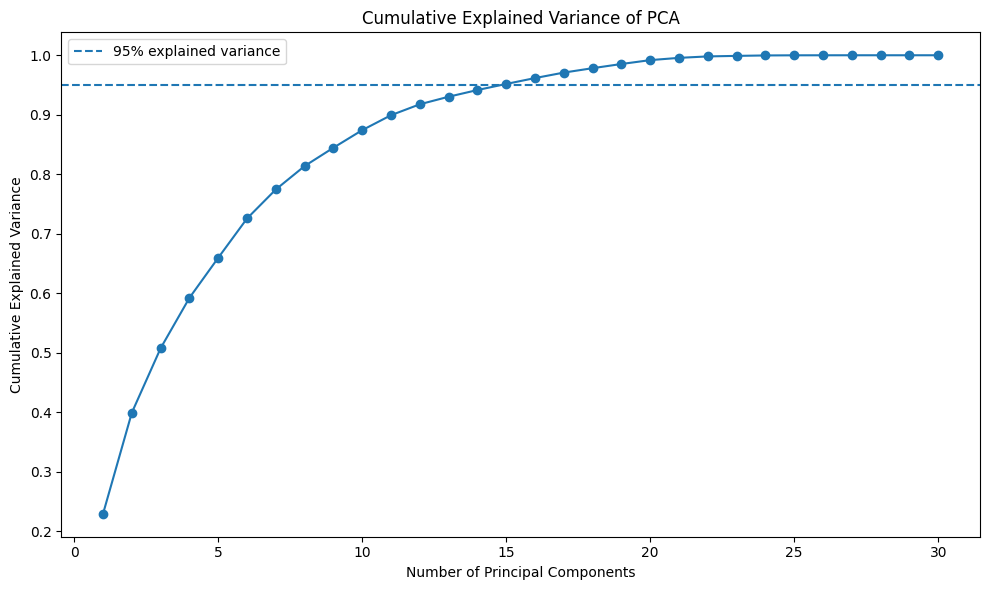

In [47]:
# Cumulative explained variance

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% explained variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance of PCA")
plt.legend()
plt.tight_layout()
plt.show()

### 4.6.3 Number of components

A threshold of **95% explained variance** is used to determine the number of principal components to retain.

The minimum number of components reaching this threshold is identified from the cumulative explained variance.

In [48]:
# Number of components for 95% explained variance

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(
    "Number of components required for 95% explained variance:",
    n_components_95
)

print(
    "Cumulative explained variance:",
    round(cumulative_variance[n_components_95 - 1] * 100, 2),
    "%"
)

Number of components required for 95% explained variance: 15
Cumulative explained variance: 95.18 %


### 4.6.4 PCA results

The PCA transformation retains **15 principal components**, reducing the selected feature space by half while preserving **95.18% of the explained variance**.

This reduced representation will be available for comparison during the modelling stage.

In [49]:
# PCA with 15 components

pca_final = PCA(n_components=n_components_95)

X_pca_final = pca_final.fit_transform(X_selected_scaled)

print("Original selected features:", X_selected.shape[1])
print("PCA components retained:", X_pca_final.shape[1])
print("Explained variance:",
      round(pca_final.explained_variance_ratio_.sum() * 100, 2), "%")

Original selected features: 30
PCA components retained: 15
Explained variance: 95.18 %


The results confirm that the 30 selected features can be represented by 15 principal components, while retaining 95.18% of the explained variance.

## 4.7 EDA & feature engineering report

The EDA and feature engineering stages provided a clearer understanding of the structure, quality, and predictive characteristics of the UNSW-NB15 dataset.

The main findings and their implications for the subsequent modelling stage are summarized below.

### 4.7.1 Main EDA findings

The dataset contains both numerical and categorical patterns that can help distinguish normal from malicious network traffic.

The target variable is moderately imbalanced, with **68.06% malicious traffic** and **31.94% normal traffic** in the training set. Numerical analysis identified substantial differences between the two classes for variables related to traffic volume, packet counts, transmission rate, load, and Time To Live values.

The categorical analysis also revealed differences across **network protocols, services, and connection states**. These relationships are treated as dataset-specific associations rather than causal indicators of malicious activity.

The correlation analysis identified several groups of highly correlated variables, particularly among traffic volume and packet-loss measures, TCP timing characteristics, and connection-count variables. This indicates that some features contain overlapping information.

### 4.7.2 Data preparation and feature engineering

The dataset required limited basic cleaning because no missing values were identified and no duplicate rows were found in the original training dataset.

The predictive feature set excludes the `id` identifier and `attack_cat`. The `id` variable is excluded because it is an identifier rather than a meaningful predictive characteristic, while `attack_cat` is retained for descriptive and analytical purposes but excluded from modelling to avoid target leakage.

Categorical variables are transformed using **One-Hot Encoding**. Numerical variables are handled according to the requirements of the modelling algorithms, with standardization applied to scale-sensitive models such as Logistic Regression.

Three additional features were created to capture aggregated traffic characteristics:

- `total_bytes`
- `total_packets`
- `bytes_ratio`

These engineered features provide additional representations of overall traffic volume and directional asymmetry and are retained as candidate predictive variables for the modelling stage.

### 4.7.3 Feature importance and explainability

Feature importance and explainability are addressed using the final Decision Tree model. Model-based feature importance is used to identify the variables contributing most to the model's decisions, while SHAP provides global and local explanations of feature contributions.

The detailed analysis is presented in section 6.1, after final model selection.

This approach avoids interpreting feature importance before the final model has been established, while ensuring that the step 3 requirement is addressed within the overall EDA and feature engineering workflow.

| Step 3 requirement | Method used | Where detailed |
|---|---|---|
| Data cleaning | Missing values, duplicates, outlier analysis | Section 4 |
| Feature engineering | Network-derived features | Section 4 |
| Feature selection | Mutual Information + SelectKBest | Section 4.5 |
| Dimensionality reduction | PCA | Section 4.6 |
| Feature importance | Decision Tree feature importance | Section 6.1 |
| Explainability | SHAP global and local | Section 6.1 |

### 4.7.4 Implications for modelling

The EDA and feature engineering results provide the basis for the modelling stage.

The analysis identified informative numerical and categorical patterns, different feature scales and distributions, class imbalance, correlations between some variables, and potential extreme observations. These characteristics are taken into consideration when defining the preprocessing and modelling approach.

For the modelling experiment, the four classification algorithms are compared using the common engineered predictive feature set rather than evaluating all combinations of models and reduced feature representations. This provides a consistent basis for comparing the algorithms and keeps the experimental design focused on the main objective of the project: evaluating the trade-off between malicious-traffic detection and false-positive alerts.

This choice also limits the computational cost and experimental complexity. Incorporating feature selection and PCA into every cross-validation pipeline would require additional transformations to be fitted repeatedly across the four models and five cross-validation folds, substantially increasing the number of experiments to be evaluated on the training dataset. Given the scope of the capstone, these additional experiments were not considered necessary to address the primary modelling objective.

The independent testing dataset will remain completely held out until the final evaluation of the selected modelling approach.

# 5. Model development, evaluation and selection

## 5.1 Modeling approach

The modelling stage evaluates the ability of supervised machine learning algorithms to distinguish between normal and malicious network traffic.

Four classification algorithms are compared:

- **Logistic Regression**
- **Decision Tree**
- **Random Forest**
- **XGBoost**

The models are first evaluated using a common baseline configuration. Their performance is compared using Stratified 5-Fold Cross-Validation applied exclusively to the training dataset.

Recall is treated as the primary detection metric because the main objective of the intrusion detection task is to identify malicious traffic and limit missed attacks. Precision, F1-score, PR-AUC, ROC-AUC, and False Positive Rate are reported as complementary performance and operational indicators.

The independent testing dataset is kept completely separate from model development. It is not used for model selection, hyperparameter tuning, or classification threshold selection. It is reserved for the final independent evaluation of the selected modelling approach.

Following the baseline comparison, targeted hyperparameter tuning is performed using cross-validation on the training dataset. The final model configuration and classification threshold are then selected before the model is refitted on the complete training dataset and evaluated once on the independent testing dataset.

This modelling strategy provides a structured progression from baseline comparison to model refinement and final independent evaluation while reducing the risk of information leakage from the testing dataset.

## 5.2 Models selection

Four supervised classification algorithms are selected for the experiment.

Logistic Regression is used as a baseline model, providing a relatively simple reference for comparison.

Decision Tree is included as an interpretable non-linear classification model.

Random Forest extends the tree-based approach through an ensemble of multiple decision trees.

XGBoost is included as a gradient boosting model capable of capturing complex non-linear relationships.

The four algorithms provide different modelling approaches and levels of model complexity, allowing their performance to be compared under the same experimental framework.

## 5.3 Data preparation

### 5.3.1 Training and testing data

In [50]:
# Prepare the training and testing data for modelling

# Training data: use the engineered feature set defined in Section 4
X_train = X_engineered.copy()
y_train = train_df[target].copy()

# Testing data: start from the original predictive features
X_test_engineered = X_test.copy()

# Recreate the same deterministic engineered features
X_test_engineered["total_bytes"] = (
    X_test_engineered["sbytes"] +
    X_test_engineered["dbytes"]
)

X_test_engineered["total_packets"] = (
    X_test_engineered["spkts"] +
    X_test_engineered["dpkts"]
)

X_test_engineered["bytes_ratio"] = (
    X_test_engineered["sbytes"] /
    (X_test_engineered["dbytes"] + 1)
)

print("Training features:", X_train.shape)
print("Training target:", y_train.shape)

print("\nTesting features:", X_test_engineered.shape)
print("Testing target:", y_test.shape)

print("\nTraining class distribution:")
display(
    y_train.value_counts(normalize=True)
)

Training features: (175341, 45)
Training target: (175341,)

Testing features: (82332, 45)
Testing target: (82332,)

Training class distribution:


,proportion
label,
1,0.680622
0,0.319378


### 5.3.2 Model-specific preprocessing

The preprocessing strategy is adapted to the characteristics of each machine learning algorithm.

Categorical variables are transformed using One-Hot Encoding for all models.

Numerical variables are standardized for Logistic Regression because this model is sensitive to differences in feature scale.

Tree-based models do not require numerical standardization because their splitting mechanisms are not sensitive to feature scale.

The preprocessing transformations are incorporated into the modelling pipelines so that they are fitted only on the training data within each cross-validation fold.

This approach ensures that each algorithm receives appropriately prepared input data while maintaining a consistent and leakage-controlled modelling process across the four models.

In [51]:
# Define the numerical and categorical features used by the modelling pipelines

model_numerical_features = (
    numerical_features
    + ["total_bytes", "total_packets", "bytes_ratio"]
)

model_categorical_features = categorical_features

print("Number of numerical modelling features:",
      len(model_numerical_features))

print("Number of categorical modelling features:",
      len(model_categorical_features))

print("\nEngineered numerical features included:")
print(["total_bytes", "total_packets", "bytes_ratio"])

Number of numerical modelling features: 42
Number of categorical modelling features: 3

Engineered numerical features included:
['total_bytes', 'total_packets', 'bytes_ratio']


## 5.4 Modelling pipelines

The preprocessing transformations are combined with the classification algorithms in modelling pipelines.

A separate preprocessing configuration is used for Logistic Regression and for the tree-based models because Logistic Regression is sensitive to the scale of numerical variables, whereas tree-based models do not require numerical standardization.

The pipelines ensure that preprocessing and model fitting are performed together within each cross-validation fold. This prevents information from the validation fold from being used to estimate preprocessing parameters.

The same pipeline structure is retained during both baseline evaluation and hyperparameter tuning.

In [52]:
# Preprocessing for Logistic Regression

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            model_numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            model_categorical_features
        )
    ]
)


# Preprocessing for tree-based models

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            model_numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            model_categorical_features
        )
    ]
)


# Build the four modelling pipelines

model_pipelines = {

    "Logistic Regression": Pipeline([
        (
            "preprocessor",
            logistic_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]),

    "Decision Tree": Pipeline([
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "XGBoost": Pipeline([
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ])
}

print("Modelling pipelines created successfully.")

for model_name in model_pipelines:
    print("-", model_name)

Modelling pipelines created successfully.
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost


## 5.5 Cross-validation strategy

A common Stratified 5-Fold Cross-Validation strategy is used for the four classification models.

The training dataset is divided into five folds while preserving a similar class distribution across the folds. For each iteration, four folds are used for training and one fold is used for validation. Each observation is therefore used for validation once.

The same cross-validation configuration is applied to Logistic Regression, Decision Tree, Random Forest, and XGBoost to provide a consistent basis for model comparison.

The modelling pipelines ensure that preprocessing transformations are fitted only on the training portion of each fold and then applied to the corresponding validation fold.

Recall is treated as the primary detection metric because the objective of the intrusion detection task is to identify malicious traffic and minimize missed attacks. Precision, F1-score, PR-AUC, ROC-AUC, and False Positive Rate are reported as complementary metrics.

The independent testing dataset is not used during cross-validation, model comparison, hyperparameter tuning, or classification threshold selection.

In [53]:
# Common cross-validation strategy

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print("Stratified 5-Fold Cross-Validation")
print("Number of folds:", cv.n_splits)
print("Random state:", cv.random_state)

Cross-validation strategy:
Stratified 5-Fold Cross-Validation
Number of folds: 5
Random state: 42


## 5.6 Logistic Regression

### 5.6.1 Baseline cross-validation

Logistic Regression is first evaluated using the common Stratified 5-Fold Cross-Validation strategy defined in Section 5.3.5.

The baseline model uses the default Logistic Regression configuration defined in the modelling pipeline. No hyperparameter tuning is performed at this stage.

For each fold, the pipeline is fitted on four training folds and evaluated on the remaining validation fold. The preprocessing transformations are fitted within the pipeline using only the corresponding training folds.

Accuracy, Recall, Precision, F1-score, PR-AUC, ROC-AUC, and False Positive Rate are calculated for each validation fold.

Recall is treated as the primary detection metric because the objective of the intrusion detection task is to identify malicious traffic and minimize missed attacks.

In [54]:
logistic_pipeline = model_pipelines["Logistic Regression"]

logistic_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    # Split the training data into fold-specific training and validation sets
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Clone the pipeline so that each fold starts from an unfitted model
    fold_model = clone(logistic_pipeline)

    # Fit only on the training portion of the current fold
    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    # Generate predictions for the validation fold
    y_pred = fold_model.predict(X_fold_val)
    y_proba = fold_model.predict_proba(X_fold_val)[:, 1]

    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(
        y_fold_val,
        y_pred
    ).ravel()

    # Evaluation metrics
    accuracy = accuracy_score(
        y_fold_val,
        y_pred
    )

    recall = recall_score(
        y_fold_val,
        y_pred
    )

    precision = precision_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    pr_auc = average_precision_score(
        y_fold_val,
        y_proba
    )

    roc_auc = roc_auc_score(
        y_fold_val,
        y_proba
    )

    fpr = fp / (fp + tn)

    # Store results for the current fold
    logistic_cv_results.append({
        "Fold": fold,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1-score": f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "FPR": fpr
    })

# Convert fold results into a DataFrame
logistic_cv_results = pd.DataFrame(
    logistic_cv_results
)

display(
    logistic_cv_results.round(4)
)

,Fold,Accuracy,Recall,Precision,F1-score,PR-AUC,ROC-AUC,FPR
0,1,0.9333,0.9884,0.9196,0.9527,0.9910,0.9833,0.1841
1,2,0.9346,0.9873,0.9221,0.9536,0.9918,0.9841,0.1777
2,3,0.9358,0.9891,0.9222,0.9545,0.9918,0.9850,0.1778
3,4,0.9368,0.9884,0.9241,0.9552,0.9923,0.9848,0.1730
4,5,0.9358,0.9866,0.9242,0.9544,0.9915,0.9840,0.1723


### 5.6.2 Cross-validation results

The performance of Logistic Regression is summarized across the five validation folds using the mean and standard deviation of each evaluation metric.

The mean provides an overall estimate of the model's validation performance, while the standard deviation indicates the variability of the results across folds.

Recall is considered the primary metric for this intrusion detection task, while Precision, F1-score, PR-AUC, ROC-AUC, and False Positive Rate provide complementary information about detection quality and false alert generation.

In [55]:
# Summarize Logistic Regression cross-validation results

logistic_cv_summary = pd.DataFrame({
    "Mean": logistic_cv_results.drop(
        columns="Fold"
    ).mean(),

    "Std": logistic_cv_results.drop(
        columns="Fold"
    ).std()
})

display(
    logistic_cv_summary.round(4)
)

,Mean,Std
Accuracy,0.9353,0.0014
Recall,0.9879,0.0010
Precision,0.9225,0.0019
F1-score,0.9541,0.0009
PR-AUC,0.9917,0.0005
ROC-AUC,0.9842,0.0007
FPR,0.1770,0.0047


### 5.6.3 Performance interpretation

The Logistic Regression baseline achieves a mean Recall of 98.79% across the five validation folds, indicating that the model detects most malicious observations during cross-validation.

The mean Precision is 92.25%, resulting in a mean F1-score of 95.41%. The model also achieves a mean PR-AUC of 99.17% and ROC-AUC of 98.42%, indicating strong discriminative and ranking performance on the validation folds.

However, the mean False Positive Rate is 17.70%, showing that a proportion of normal traffic is classified as malicious. This represents an important operational consideration for an intrusion detection system, where excessive false alerts may increase the workload associated with investigating alerts.

The relatively small standard deviations across the five folds indicate that the model's performance is consistent across the different validation subsets.

These results establish Logistic Regression as the linear baseline against which the three non-linear tree-based models will be compared.

## 5.7 Decision Tree

### 5.7.1 Baseline cross-validation

Decision Tree is evaluated using the same Stratified 5-Fold Cross-Validation strategy as Logistic Regression.

The baseline model uses the default Decision Tree configuration defined in the modelling pipeline. No hyperparameter tuning is performed at this stage.

For each fold, the pipeline is fitted on four training folds and evaluated on the remaining validation fold. The preprocessing transformations are therefore fitted only on the corresponding training portion of each fold.

Accuracy, Recall, Precision, F1-score, PR-AUC, ROC-AUC, and False Positive Rate are calculated for each validation fold.

Recall remains the primary detection metric, while the other metrics provide complementary information about classification performance and false alert generation.

In [56]:
# Baseline cross-validation for Decision Tree

decision_tree_pipeline = model_pipelines["Decision Tree"]

decision_tree_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    # Split the training data into fold-specific training and validation sets
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Clone the pipeline so that each fold starts from an unfitted model
    fold_model = clone(decision_tree_pipeline)

    # Fit only on the training portion of the current fold
    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    # Generate predictions and probabilities for the validation fold
    y_pred = fold_model.predict(X_fold_val)
    y_proba = fold_model.predict_proba(X_fold_val)[:, 1]

    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(
        y_fold_val,
        y_pred
    ).ravel()

    # Evaluation metrics
    accuracy = accuracy_score(
        y_fold_val,
        y_pred
    )

    recall = recall_score(
        y_fold_val,
        y_pred
    )

    precision = precision_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    pr_auc = average_precision_score(
        y_fold_val,
        y_proba
    )

    roc_auc = roc_auc_score(
        y_fold_val,
        y_proba
    )

    fpr = fp / (fp + tn)

    # Store results for the current fold
    decision_tree_cv_results.append({
        "Fold": fold,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1-score": f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "FPR": fpr
    })

# Convert fold results into a DataFrame
decision_tree_cv_results = pd.DataFrame(
    decision_tree_cv_results
)

display(
    decision_tree_cv_results.round(4)
)

,Fold,Accuracy,Recall,Precision,F1-score,PR-AUC,ROC-AUC,FPR
0,1,0.9472,0.9603,0.9621,0.9612,0.9524,0.9417,0.0806
1,2,0.9490,0.9615,0.9634,0.9625,0.9535,0.9430,0.0779
2,3,0.9510,0.9640,0.9641,0.9640,0.9547,0.9449,0.0765
3,4,0.9477,0.9596,0.9634,0.9615,0.9536,0.9430,0.0776
4,5,0.9485,0.9625,0.9618,0.9622,0.9526,0.9422,0.0814


### 5.7.2 Cross-validation results

The performance of the Decision Tree baseline is summarized across the five validation folds using the mean and standard deviation of each evaluation metric.

The mean provides an overall estimate of validation performance, while the standard deviation indicates the variability of the results across folds.

The results will subsequently be compared with the Logistic Regression baseline and with the other non-linear models using the same evaluation framework.

In [57]:
# Summarize Decision Tree cross-validation results

decision_tree_cv_summary = pd.DataFrame({
    "Mean": decision_tree_cv_results.drop(
        columns="Fold"
    ).mean(),

    "Std": decision_tree_cv_results.drop(
        columns="Fold"
    ).std()
})

display(
    decision_tree_cv_summary.round(4)
)

,Mean,Std
Accuracy,0.9487,0.0015
Recall,0.9616,0.0017
Precision,0.9630,0.0010
F1-score,0.9623,0.0011
PR-AUC,0.9534,0.0009
ROC-AUC,0.9430,0.0012
FPR,0.0788,0.0021


### 5.7.3 Performance interpretation

The Decision Tree baseline achieves a mean Recall of 96.16% across the five validation folds, indicating that the model detects the large majority of malicious observations during cross-validation.

The model achieves a mean Precision of 96.30% and a mean F1-score of 96.23%. Compared with the Logistic Regression baseline, the Decision Tree produces a lower mean Recall but a higher mean Precision and F1-score.

The mean False Positive Rate is 7.88%, which is substantially lower than the 17.70% observed for Logistic Regression. This indicates that the Decision Tree generates fewer false positive classifications of normal traffic under the baseline configuration.

The PR-AUC and ROC-AUC values are 95.34% and 94.30%, respectively. These metrics provide complementary information about the model's ability to distinguish between malicious and normal observations across different classification thresholds.

The standard deviations remain relatively small across the five folds, indicating consistent performance across the validation subsets.

These results illustrate a different trade-off from Logistic Regression: the Decision Tree provides higher Precision and a lower False Positive Rate, while Logistic Regression provides higher Recall. This difference will be considered when comparing the four baseline models using the common evaluation framework.

## 5.8 Random Forest

### 5.8.1 Baseline cross-validation

Random Forest is evaluated using the same Stratified 5-Fold Cross-Validation strategy applied to the previous models.

The baseline model uses the configuration defined in the modelling pipeline, with 200 decision trees and a fixed random state to support reproducibility. No hyperparameter tuning is performed at this stage.

For each fold, the pipeline is fitted on four training folds and evaluated on the remaining validation fold. The preprocessing transformations are fitted only on the corresponding training portion of each fold.

Accuracy, Recall, Precision, F1-score, PR-AUC, ROC-AUC, and False Positive Rate are calculated for each validation fold.

Recall remains the primary detection metric, while the other metrics provide complementary information about classification performance and false alert generation.

In [58]:
# Baseline cross-validation for Random Forest

random_forest_pipeline = model_pipelines["Random Forest"]

random_forest_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    # Split the training data into fold-specific training and validation sets
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Clone the pipeline so that each fold starts from an unfitted model
    fold_model = clone(random_forest_pipeline)

    # Fit only on the training portion of the current fold
    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    # Generate predictions and probabilities for the validation fold
    y_pred = fold_model.predict(X_fold_val)
    y_proba = fold_model.predict_proba(X_fold_val)[:, 1]

    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(
        y_fold_val,
        y_pred
    ).ravel()

    # Evaluation metrics
    accuracy = accuracy_score(
        y_fold_val,
        y_pred
    )

    recall = recall_score(
        y_fold_val,
        y_pred
    )

    precision = precision_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    pr_auc = average_precision_score(
        y_fold_val,
        y_proba
    )

    roc_auc = roc_auc_score(
        y_fold_val,
        y_proba
    )

    fpr = fp / (fp + tn)

    # Store results for the current fold
    random_forest_cv_results.append({
        "Fold": fold,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1-score": f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "FPR": fpr
    })

# Convert fold results into a DataFrame
random_forest_cv_results = pd.DataFrame(
    random_forest_cv_results
)

display(
    random_forest_cv_results.round(4)
)

,Fold,Accuracy,Recall,Precision,F1-score,PR-AUC,ROC-AUC,FPR
0,1,0.9591,0.9783,0.9622,0.9702,0.9969,0.9937,0.0819
1,2,0.9603,0.9788,0.9635,0.9711,0.9968,0.9938,0.0791
2,3,0.9616,0.9808,0.9634,0.9720,0.9970,0.9942,0.0795
3,4,0.9608,0.9786,0.9644,0.9714,0.9972,0.9944,0.0771
4,5,0.9585,0.9777,0.9620,0.9698,0.9966,0.9936,0.0822


### 5.8.2 Cross-validation results

The performance of the Random Forest baseline is summarized across the five validation folds using the mean and standard deviation of each evaluation metric.

The mean provides an overall estimate of validation performance, while the standard deviation indicates the variability of the results across folds.

The results will be compared with the Logistic Regression and Decision Tree baselines using the same evaluation framework.

In [59]:
# Summarize Random Forest cross-validation results

random_forest_cv_summary = pd.DataFrame({
    "Mean": random_forest_cv_results.drop(
        columns="Fold"
    ).mean(),

    "Std": random_forest_cv_results.drop(
        columns="Fold"
    ).std()
})

display(
    random_forest_cv_summary.round(4)
)

,Mean,Std
Accuracy,0.9601,0.0013
Recall,0.9788,0.0012
Precision,0.9631,0.0010
F1-score,0.9709,0.0009
PR-AUC,0.9969,0.0002
ROC-AUC,0.9939,0.0004
FPR,0.0799,0.0021


### 5.8.3 Performance interpretation

The Random Forest baseline achieves a mean Recall of 97.88% across the five validation folds, indicating that the model detects the large majority of malicious observations during cross-validation.

The model achieves a mean Precision of 96.31% and a mean F1-score of 97.09%, showing a relatively balanced performance between detecting malicious traffic and limiting incorrect positive classifications.

The mean PR-AUC is 99.69% and the mean ROC-AUC is 99.39%, indicating strong discriminatory and ranking performance across the validation folds.

The mean False Positive Rate is 7.99%, meaning that approximately 8% of normal observations are classified as malicious under the baseline classification threshold. This remains an important operational consideration for an intrusion detection system.

The standard deviations are small across all metrics, indicating that the Random Forest produces consistent results across the five validation folds.

Compared with the previous baseline models, the Random Forest shows a different performance profile, combining high Recall with high Precision and a relatively low False Positive Rate. These results will be considered together with the Logistic Regression, Decision Tree, and XGBoost baselines in the overall model comparison.

## 5.9 XGBoost

### 5.9.1 Baseline cross-validation

XGBoost is evaluated using the same Stratified 5-Fold Cross-Validation strategy applied to the three previous classification models.

The baseline model uses the configuration defined in the modelling pipeline, with 200 boosting estimators, a maximum tree depth of 6, and a learning rate of 0.1. No hyperparameter tuning is performed at this stage.

For each fold, the pipeline is fitted on four training folds and evaluated on the remaining validation fold. The preprocessing transformations are fitted only on the corresponding training portion of each fold.

Accuracy, Recall, Precision, F1-score, PR-AUC, ROC-AUC, and False Positive Rate are calculated for each validation fold.

Recall remains the primary detection metric, while the other metrics provide complementary information about classification performance and false alert generation.

In [60]:
# Baseline cross-validation for XGBoost

xgboost_pipeline = model_pipelines["XGBoost"]

xgboost_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    # Split the training data into fold-specific training and validation sets
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Clone the pipeline so that each fold starts from an unfitted model
    fold_model = clone(xgboost_pipeline)

    # Fit only on the training portion of the current fold
    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    # Generate predictions and probabilities for the validation fold
    y_pred = fold_model.predict(X_fold_val)
    y_proba = fold_model.predict_proba(X_fold_val)[:, 1]

    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(
        y_fold_val,
        y_pred
    ).ravel()

    # Evaluation metrics
    accuracy = accuracy_score(
        y_fold_val,
        y_pred
    )

    recall = recall_score(
        y_fold_val,
        y_pred
    )

    precision = precision_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_fold_val,
        y_pred,
        zero_division=0
    )

    pr_auc = average_precision_score(
        y_fold_val,
        y_proba
    )

    roc_auc = roc_auc_score(
        y_fold_val,
        y_proba
    )

    fpr = fp / (fp + tn)

    # Store results for the current fold
    xgboost_cv_results.append({
        "Fold": fold,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1-score": f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "FPR": fpr
    })

# Convert fold results into a DataFrame
xgboost_cv_results = pd.DataFrame(
    xgboost_cv_results
)

display(
    xgboost_cv_results.round(4)
)

,Fold,Accuracy,Recall,Precision,F1-score,PR-AUC,ROC-AUC,FPR
0,1,0.9557,0.9761,0.9596,0.9678,0.9968,0.9932,0.0877
1,2,0.9574,0.9770,0.9611,0.9689,0.9968,0.9932,0.0844
2,3,0.9599,0.9785,0.9632,0.9708,0.9970,0.9938,0.0796
3,4,0.9587,0.9790,0.9611,0.9700,0.9972,0.9940,0.0845
4,5,0.9567,0.9757,0.9613,0.9684,0.9967,0.9931,0.0838


### 5.9.2 Cross-validation results

The performance of the XGBoost baseline is summarized across the five validation folds using the mean and standard deviation of each evaluation metric.

The mean provides an overall estimate of validation performance, while the standard deviation indicates the variability of the results across folds.

The results will complete the baseline evaluation of the four classification models and will subsequently be compared using the same evaluation framework.

In [61]:
# Summarize XGBoost cross-validation results

xgboost_cv_summary = pd.DataFrame({
    "Mean": xgboost_cv_results.drop(
        columns="Fold"
    ).mean(),

    "Std": xgboost_cv_results.drop(
        columns="Fold"
    ).std()
})

display(
    xgboost_cv_summary.round(4)
)

,Mean,Std
Accuracy,0.9577,0.0017
Recall,0.9773,0.0015
Precision,0.9612,0.0013
F1-score,0.9692,0.0012
PR-AUC,0.9969,0.0002
ROC-AUC,0.9934,0.0004
FPR,0.0840,0.0029


### 5.9.3 Performance interpretation

The XGBoost baseline achieves a mean Recall of 97.73% across the five validation folds, indicating that the model detects the large majority of malicious observations during cross-validation.

The model achieves a mean Precision of 96.12% and a mean F1-score of 96.92%, indicating a balanced performance between detecting malicious traffic and limiting incorrect positive classifications.

The mean PR-AUC is 99.69% and the mean ROC-AUC is 99.34%, indicating strong discriminatory and ranking performance across the validation folds.

The mean False Positive Rate is 8.40%, meaning that a proportion of normal observations is classified as malicious under the baseline classification threshold. This remains an important operational consideration for an intrusion detection system.

The standard deviations are small across all metrics, indicating consistent performance across the five validation folds.

These results complete the baseline evaluation of the four classification models. The differences in Recall, Precision, F1-score, ranking performance, and False Positive Rate will be examined jointly in the baseline model comparison.

## 5.10 Baseline model comparison

The four classification models are now compared using the results obtained from the same Stratified 5-Fold Cross-Validation procedure.

All models were evaluated on the same training dataset, using the same feature representation, cross-validation strategy, and evaluation metrics.

Recall is treated as the primary detection metric, while Precision, F1-score, PR-AUC, ROC-AUC, and False Positive Rate provide complementary information about detection performance and potential false alert generation.

This comparison is conducted before hyperparameter tuning. The independent testing dataset has not been used in this comparison.

In [62]:
# Compile baseline cross-validation results for all four models

baseline_summaries = {
    "Logistic Regression": logistic_cv_summary,
    "Decision Tree": decision_tree_cv_summary,
    "Random Forest": random_forest_cv_summary,
    "XGBoost": xgboost_cv_summary
}

baseline_comparison = pd.DataFrame({
    model_name: summary["Mean"]
    for model_name, summary in baseline_summaries.items()
}).T

baseline_comparison = baseline_comparison[
    [
        "Accuracy",
        "Recall",
        "Precision",
        "F1-score",
        "PR-AUC",
        "ROC-AUC",
        "FPR"
    ]
]

display(
    baseline_comparison.round(4)
)

,Accuracy,Recall,Precision,F1-score,PR-AUC,ROC-AUC,FPR
Logistic Regression,0.9353,0.9879,0.9225,0.9541,0.9917,0.9842,0.1770
Decision Tree,0.9487,0.9616,0.9630,0.9623,0.9534,0.9430,0.0788
Random Forest,0.9601,0.9788,0.9631,0.9709,0.9969,0.9939,0.0799
XGBoost,0.9577,0.9773,0.9612,0.9692,0.9969,0.9934,0.0840


### 5.10.1 Baseline comparison interpretation

The baseline cross-validation results show that the four models achieve strong classification performance, but with different performance profiles.

Logistic Regression achieves the highest mean Recall among the four baseline models at 98.79%. However, it also has the highest mean False Positive Rate at 17.70%, together with a lower mean Precision than the three tree-based models.

The Decision Tree achieves a mean Recall of 96.16% and a mean Precision of 96.30%, with a mean False Positive Rate of 7.88%. Its results therefore show a different balance between malicious traffic detection and false positive classification.

Random Forest achieves a mean Recall of 97.88%, with a mean Precision of 96.31%, a mean F1-score of 97.09%, and a mean False Positive Rate of 7.99%. Its PR-AUC and ROC-AUC are also high at 99.69% and 99.39%, respectively.

XGBoost achieves a mean Recall of 97.73%, a mean Precision of 96.12%, and a mean F1-score of 96.92%. Its mean PR-AUC and ROC-AUC are 99.69% and 99.34%, respectively, with a mean False Positive Rate of 8.40%.

The baseline comparison demonstrates that model choice involves trade-offs between attack detection, precision, ranking performance, and false positive generation. These results provide the basis for the next stage of the modelling process: targeted hyperparameter tuning using cross-validation on the training dataset only.

The independent testing dataset remains untouched and will only be used for the final evaluation after model and threshold selection have been completed.

## 5.11 Hyperparameter tuning

### 5.11.1 Logistic Regression tuning

The Logistic Regression model is tuned using Grid Search with Stratified 5-Fold Cross-Validation.

The hyperparameter selected for tuning is `C`, which controls the strength of regularization. Several candidate values are evaluated using the training dataset only.

For each candidate value, the complete modelling pipeline is evaluated using the same five cross-validation folds defined previously.

Mean Recall is used as the primary selection criterion because minimizing missed attacks is the main objective of the intrusion detection task.

The independent testing dataset is not used during hyperparameter tuning.

In [63]:
# Define the Logistic Regression hyperparameter search space

logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

print("Logistic Regression hyperparameter search space:")
print(logistic_param_grid)

Logistic Regression hyperparameter search space:
{'classifier__C': [0.01, 0.1, 1, 10, 100]}


In [64]:
# Define the metrics used during hyperparameter tuning

tuning_scoring = {
    "Recall": "recall",
    "Precision": "precision",
    "F1-score": "f1",
    "PR-AUC": "average_precision",
    "ROC-AUC": "roc_auc"
}

# Configure Grid Search
logistic_grid_search = GridSearchCV(
    estimator=model_pipelines["Logistic Regression"],
    param_grid=logistic_param_grid,
    scoring=tuning_scoring,
    refit="Recall",
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

# Run hyperparameter tuning on the training data only
logistic_grid_search.fit(
    X_train,
    y_train
)

print("Logistic Regression tuning completed.")
print(
    "Best hyperparameter:",
    logistic_grid_search.best_params_
)
print(
    "Best mean CV Recall:",
    round(
        logistic_grid_search.best_score_,
        4
    )
)

Logistic Regression tuning completed.
Best hyperparameter: {'classifier__C': 0.01}
Best mean CV Recall: 0.9905


### Logistic Regression tuning results

The Grid Search results are examined using the mean cross-validation performance obtained for each candidate value of `C`.

The selected configuration is the one achieving the highest mean Recall across the five validation folds. The other metrics are retained to examine the trade-offs associated with the selected hyperparameter.

In [65]:
# Extract and display Logistic Regression tuning results

logistic_tuning_results = pd.DataFrame(
    logistic_grid_search.cv_results_
)

logistic_tuning_results = logistic_tuning_results[
    [
        "param_classifier__C",
        "mean_test_Recall",
        "std_test_Recall",
        "mean_test_Precision",
        "mean_test_F1-score",
        "mean_test_PR-AUC",
        "mean_test_ROC-AUC"
    ]
].copy()

logistic_tuning_results = logistic_tuning_results.rename(
    columns={
        "param_classifier__C": "C",
        "mean_test_Recall": "Mean Recall",
        "std_test_Recall": "Recall Std",
        "mean_test_Precision": "Mean Precision",
        "mean_test_F1-score": "Mean F1-score",
        "mean_test_PR-AUC": "Mean PR-AUC",
        "mean_test_ROC-AUC": "Mean ROC-AUC"
    }
)

display(
    logistic_tuning_results.round(4)
)

,C,Mean Recall,Recall Std,Mean Precision,Mean F1-score,Mean PR-AUC,Mean ROC-AUC
0,0.01,0.9905,0.0008,0.9166,0.9521,0.9901,0.9807
1,0.10,0.9888,0.0008,0.9202,0.9533,0.9913,0.9834
2,1.00,0.9880,0.0009,0.9225,0.9541,0.9917,0.9842
3,10.00,0.9876,0.0009,0.9237,0.9546,0.9918,0.9845
4,100.00,0.9876,0.0007,0.9241,0.9548,0.9919,0.9846


### Logistic Regression tuning interpretation

The Grid Search selects `C=0.01`, which achieves the highest mean cross-validation Recall of 99.05%.

Compared with the baseline configuration (`C=1`), the selected configuration increases mean Recall from 98.80% to 99.05%. This improvement is accompanied by a decrease in mean Precision from 92.25% to 91.66% and in mean F1-score from 95.41% to 95.21%.

The selected configuration therefore reflects the prioritization of Recall defined for this intrusion detection task. The results also illustrate the trade-off between detecting a larger proportion of malicious observations and limiting false positive classifications.

The differences in PR-AUC and ROC-AUC across the candidate values are relatively small, ranging from 99.01% to 99.19% for PR-AUC and from 98.07% to 98.46% for ROC-AUC.

The selected hyperparameter is retained for the subsequent tuned-model comparison. The independent testing dataset has not been used during this selection process.

### 5.11.2 Decision Tree tuning

The Decision Tree model is tuned using Grid Search with Stratified 5-Fold Cross-Validation.

The hyperparameter selected for tuning is `max_depth`, which controls the maximum depth of the decision tree and therefore the complexity of the model.

Five candidate values are evaluated using the training dataset only. For each candidate value, the complete modelling pipeline is evaluated using the same five cross-validation folds defined previously.

Mean Recall is used as the primary selection criterion because minimizing missed attacks is the main objective of the intrusion detection task.

The independent testing dataset is not used during hyperparameter tuning.

In [66]:
# Define the Decision Tree hyperparameter search space

decision_tree_param_grid = {
    "classifier__max_depth": [3, 5, 10, 20, None]
}

print("Decision Tree hyperparameter search space:")
print(decision_tree_param_grid)

Decision Tree hyperparameter search space:
{'classifier__max_depth': [3, 5, 10, 20, None]}


In [67]:
# Configure Grid Search for Decision Tree

decision_tree_grid_search = GridSearchCV(
    estimator=model_pipelines["Decision Tree"],
    param_grid=decision_tree_param_grid,
    scoring=tuning_scoring,
    refit="Recall",
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

# Run hyperparameter tuning on the training data only
decision_tree_grid_search.fit(
    X_train,
    y_train
)

print("Decision Tree tuning completed.")
print(
    "Best hyperparameter:",
    decision_tree_grid_search.best_params_
)
print(
    "Best mean CV Recall:",
    round(
        decision_tree_grid_search.best_score_,
        4
    )
)

Decision Tree tuning completed.
Best hyperparameter: {'classifier__max_depth': 3}
Best mean CV Recall: 1.0


### Decision Tree tuning results

The Grid Search results are examined using the mean cross-validation performance obtained for each candidate value of `max_depth`.

The selected configuration is the one achieving the highest mean Recall across the five validation folds. The other metrics are retained to examine the trade-offs associated with the selected tree depth.

In [68]:
# Extract and display Decision Tree tuning results

decision_tree_tuning_results = pd.DataFrame(
    decision_tree_grid_search.cv_results_
)

decision_tree_tuning_results = decision_tree_tuning_results[
    [
        "param_classifier__max_depth",
        "mean_test_Recall",
        "std_test_Recall",
        "mean_test_Precision",
        "mean_test_F1-score",
        "mean_test_PR-AUC",
        "mean_test_ROC-AUC"
    ]
].copy()

decision_tree_tuning_results = decision_tree_tuning_results.rename(
    columns={
        "param_classifier__max_depth": "max_depth",
        "mean_test_Recall": "Mean Recall",
        "std_test_Recall": "Recall Std",
        "mean_test_Precision": "Mean Precision",
        "mean_test_F1-score": "Mean F1-score",
        "mean_test_PR-AUC": "Mean PR-AUC",
        "mean_test_ROC-AUC": "Mean ROC-AUC"
    }
)

display(
    decision_tree_tuning_results.round(4)
)

,max_depth,Mean Recall,Recall Std,Mean Precision,Mean F1-score,Mean PR-AUC,Mean ROC-AUC
0,3,1.0000,0.0000,0.8976,0.9460,0.9760,0.9696
1,5,0.9973,0.0006,0.9154,0.9546,0.9879,0.9827
2,10,0.9576,0.0019,0.9603,0.9590,0.9929,0.9883
3,20,0.9627,0.0012,0.9639,0.9633,0.9742,0.9675
4,None,0.9616,0.0016,0.9630,0.9623,0.9534,0.9430


### Decision Tree tuning interpretation

The Grid Search selects `max_depth=3`, which achieves the highest mean cross-validation Recall of 100.00%.

This configuration increases the mean Recall from 96.16% for the baseline Decision Tree to 100.00% during cross-validation. However, the increase in Recall is associated with a lower mean Precision of 89.76% and a mean F1-score of 94.60%.

The results also show that deeper trees provide a different performance profile. For example, `max_depth=10` achieves a lower mean Recall of 95.76%, but higher Precision, F1-score, PR-AUC, and ROC-AUC values than the selected depth of 3.

The selected configuration therefore reflects the prioritization of Recall defined for this intrusion detection task rather than optimization of all metrics simultaneously.

The standard deviation of Recall for `max_depth=3` is 0.0000, indicating that the 100% Recall was obtained consistently across the five validation folds.

The selected hyperparameter is retained for the subsequent tuned-model comparison. The independent testing dataset has not been used during this selection process.

### 5.11.3 Random Forest tuning

The Random Forest model is tuned using Grid Search with Stratified 5-Fold Cross-Validation.

Two hyperparameters are selected for tuning: `max_depth`, which controls the maximum depth of each decision tree, and `min_samples_leaf`, which controls the minimum number of observations required in a leaf.

Four combinations of these hyperparameters are evaluated using the training dataset only. For each combination, the complete modelling pipeline is evaluated using the same five cross-validation folds defined previously.

Mean Recall is used as the primary selection criterion because minimizing missed attacks is the main objective of the intrusion detection task.

The independent testing dataset is not used during hyperparameter tuning.

In [69]:
# Define the Random Forest hyperparameter search space

rf_param_grid = {
    "classifier__max_depth": [10, 20],
    "classifier__min_samples_leaf": [1, 5]
}

print("Random Forest hyperparameter search space:")
print(rf_param_grid)

Random Forest hyperparameter search space:
{'classifier__max_depth': [10, 20], 'classifier__min_samples_leaf': [1, 5]}


In [70]:
# Configure Grid Search for Random Forest

random_forest_grid_search = GridSearchCV(
    estimator=model_pipelines["Random Forest"],
    param_grid=rf_param_grid,
    scoring=tuning_scoring,
    refit="Recall",
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

# Run hyperparameter tuning on the training data only
random_forest_grid_search.fit(
    X_train,
    y_train
)

print("Random Forest tuning completed.")
print(
    "Best hyperparameters:",
    random_forest_grid_search.best_params_
)
print(
    "Best mean CV Recall:",
    round(
        random_forest_grid_search.best_score_,
        4
    )
)

Random Forest tuning completed.
Best hyperparameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5}
Best mean CV Recall: 0.9945


### Random Forest tuning results

The Grid Search results are examined using the mean cross-validation performance obtained for each combination of `max_depth` and `min_samples_leaf`.

The selected configuration is the combination achieving the highest mean Recall across the five validation folds. The other metrics are retained to examine the trade-offs associated with the selected hyperparameters.

In [71]:
# Extract and display Random Forest tuning results

random_forest_tuning_results = pd.DataFrame(
    random_forest_grid_search.cv_results_
)

random_forest_tuning_results = random_forest_tuning_results[
    [
        "param_classifier__max_depth",
        "param_classifier__min_samples_leaf",
        "mean_test_Recall",
        "std_test_Recall",
        "mean_test_Precision",
        "mean_test_F1-score",
        "mean_test_PR-AUC",
        "mean_test_ROC-AUC"
    ]
].copy()

random_forest_tuning_results = (
    random_forest_tuning_results.rename(
        columns={
            "param_classifier__max_depth": "max_depth",
            "param_classifier__min_samples_leaf": "min_samples_leaf",
            "mean_test_Recall": "Mean Recall",
            "std_test_Recall": "Recall Std",
            "mean_test_Precision": "Mean Precision",
            "mean_test_F1-score": "Mean F1-score",
            "mean_test_PR-AUC": "Mean PR-AUC",
            "mean_test_ROC-AUC": "Mean ROC-AUC"
        }
    )
)

display(
    random_forest_tuning_results.round(4)
)

,max_depth,min_samples_leaf,Mean Recall,Recall Std,Mean Precision,Mean F1-score,Mean PR-AUC,Mean ROC-AUC
0,10,1,0.9943,0.0006,0.9258,0.9588,0.9956,0.9907
1,10,5,0.9945,0.0010,0.9252,0.9586,0.9955,0.9905
2,20,1,0.9823,0.0012,0.9591,0.9706,0.9971,0.9939
3,20,5,0.9843,0.0007,0.9521,0.9679,0.9968,0.9932


### Random Forest tuning interpretation

The Grid Search selects the combination `max_depth=10` and `min_samples_leaf=5`, which achieves the highest mean cross-validation Recall of 99.45%.

Compared with the baseline Random Forest, which achieved a mean Recall of 97.88%, the selected configuration increases Recall by 1.57 percentage points.

However, this increase in Recall is accompanied by a decrease in mean Precision from 96.31% to 92.52% and in mean F1-score from 97.09% to 95.86%. The mean PR-AUC and ROC-AUC also decrease slightly compared with the baseline configuration.

The results therefore illustrate a clear trade-off between maximizing attack detection and maintaining precision and overall classification balance.

The selected configuration is retained because Recall was defined in advance as the primary selection criterion for the intrusion detection task. The independent testing dataset has not been used during this selection process.

### 5.11.4 XGBoost tuning

The XGBoost model is tuned using Grid Search with Stratified 5-Fold Cross-Validation.

Two hyperparameters are selected for tuning: `max_depth`, which controls the maximum depth of the boosting trees, and `learning_rate`, which controls the contribution of each boosting iteration to the final model.

Four combinations of these hyperparameters are evaluated using the training dataset only. For each combination, the complete modelling pipeline is evaluated using the same five cross-validation folds defined previously.

Mean Recall is used as the primary selection criterion because minimizing missed attacks is the main objective of the intrusion detection task.

The independent testing dataset is not used during hyperparameter tuning.

In [72]:
# Define the XGBoost hyperparameter search space

xgb_param_grid = {
    "classifier__max_depth": [4, 6],
    "classifier__learning_rate": [0.05, 0.1]
}

print("XGBoost hyperparameter search space:")
print(xgb_param_grid)

XGBoost hyperparameter search space:
{'classifier__max_depth': [4, 6], 'classifier__learning_rate': [0.05, 0.1]}


In [73]:
# Configure Grid Search for XGBoost

xgboost_grid_search = GridSearchCV(
    estimator=model_pipelines["XGBoost"],
    param_grid=xgb_param_grid,
    scoring=tuning_scoring,
    refit="Recall",
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

# Run hyperparameter tuning on the training data only
xgboost_grid_search.fit(
    X_train,
    y_train
)

print("XGBoost tuning completed.")
print(
    "Best hyperparameters:",
    xgboost_grid_search.best_params_
)
print(
    "Best mean CV Recall:",
    round(
        xgboost_grid_search.best_score_,
        4
    )
)

XGBoost tuning completed.
Best hyperparameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4}
Best mean CV Recall: 0.9779


### XGBoost tuning results

The Grid Search results are examined using the mean cross-validation performance obtained for each combination of `max_depth` and `learning_rate`.

The selected configuration is the combination achieving the highest mean Recall across the five validation folds. The other metrics are retained to examine the trade-offs associated with the selected hyperparameters.

In [74]:
# Extract and display XGBoost tuning results

xgboost_tuning_results = pd.DataFrame(
    xgboost_grid_search.cv_results_
)

xgboost_tuning_results = xgboost_tuning_results[
    [
        "param_classifier__max_depth",
        "param_classifier__learning_rate",
        "mean_test_Recall",
        "std_test_Recall",
        "mean_test_Precision",
        "mean_test_F1-score",
        "mean_test_PR-AUC",
        "mean_test_ROC-AUC"
    ]
].copy()

xgboost_tuning_results = (
    xgboost_tuning_results.rename(
        columns={
            "param_classifier__max_depth": "max_depth",
            "param_classifier__learning_rate": "learning_rate",
            "mean_test_Recall": "Mean Recall",
            "std_test_Recall": "Recall Std",
            "mean_test_Precision": "Mean Precision",
            "mean_test_F1-score": "Mean F1-score",
            "mean_test_PR-AUC": "Mean PR-AUC",
            "mean_test_ROC-AUC": "Mean ROC-AUC"
        }
    )
)

display(
    xgboost_tuning_results.round(4)
)

,max_depth,learning_rate,Mean Recall,Recall Std,Mean Precision,Mean F1-score,Mean PR-AUC,Mean ROC-AUC
0,4,0.05,0.9779,0.0018,0.9495,0.9635,0.9956,0.9908
1,6,0.05,0.9774,0.0015,0.9553,0.9662,0.9963,0.9923
2,4,0.10,0.9760,0.0013,0.9562,0.9660,0.9962,0.9921
3,6,0.10,0.9773,0.0013,0.9612,0.9692,0.9969,0.9934


### XGBoost tuning interpretation

The Grid Search selects the combination `max_depth=4` and `learning_rate=0.05`, which achieves the highest mean cross-validation Recall of 97.79%.

Compared with the baseline XGBoost configuration, which achieved a mean Recall of 97.73%, the selected configuration produces only a small increase in Recall.

The selected configuration achieves a mean Precision of 94.95% and a mean F1-score of 96.35%. Other configurations provide slightly higher Precision, F1-score, PR-AUC, and ROC-AUC, but none achieves a higher mean Recall.

The difference in Recall between the four tested configurations is small, indicating that the selected hyperparameter combination does not substantially change the model's detection performance within the tested search space.

The selected configuration is retained because Recall was defined in advance as the primary selection criterion for the intrusion detection task. The independent testing dataset has not been used during this selection process.

### 5.11.5 Tuned model comparison

The four tuned classification models are compared using the cross-validation results obtained during hyperparameter tuning.

For each model, the configuration selected through Grid Search is reported together with its mean cross-validation performance.

The comparison includes Recall as the primary detection metric, together with Precision, F1-score, PR-AUC, and ROC-AUC as complementary measures.

The models were tuned independently using the same Stratified 5-Fold Cross-Validation strategy and the training dataset only.

The independent testing dataset has not been used for model selection or hyperparameter tuning.

In [75]:
# Compile the selected configurations and their cross-validation performance

tuned_models = {
    "Logistic Regression": logistic_grid_search,
    "Decision Tree": decision_tree_grid_search,
    "Random Forest": random_forest_grid_search,
    "XGBoost": xgboost_grid_search
}

tuned_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Selected parameters": [
        str(logistic_grid_search.best_params_),
        str(decision_tree_grid_search.best_params_),
        str(random_forest_grid_search.best_params_),
        str(xgboost_grid_search.best_params_)
    ],

    "Mean Recall": [
        logistic_grid_search.best_score_,
        decision_tree_grid_search.best_score_,
        random_forest_grid_search.best_score_,
        xgboost_grid_search.best_score_
    ],

    "Mean Precision": [
        logistic_grid_search.cv_results_[
            "mean_test_Precision"
        ][logistic_grid_search.best_index_],

        decision_tree_grid_search.cv_results_[
            "mean_test_Precision"
        ][decision_tree_grid_search.best_index_],

        random_forest_grid_search.cv_results_[
            "mean_test_Precision"
        ][random_forest_grid_search.best_index_],

        xgboost_grid_search.cv_results_[
            "mean_test_Precision"
        ][xgboost_grid_search.best_index_]
    ],

    "Mean F1-score": [
        logistic_grid_search.cv_results_[
            "mean_test_F1-score"
        ][logistic_grid_search.best_index_],

        decision_tree_grid_search.cv_results_[
            "mean_test_F1-score"
        ][decision_tree_grid_search.best_index_],

        random_forest_grid_search.cv_results_[
            "mean_test_F1-score"
        ][random_forest_grid_search.best_index_],

        xgboost_grid_search.cv_results_[
            "mean_test_F1-score"
        ][xgboost_grid_search.best_index_]
    ],

    "Mean PR-AUC": [
        logistic_grid_search.cv_results_[
            "mean_test_PR-AUC"
        ][logistic_grid_search.best_index_],

        decision_tree_grid_search.cv_results_[
            "mean_test_PR-AUC"
        ][decision_tree_grid_search.best_index_],

        random_forest_grid_search.cv_results_[
            "mean_test_PR-AUC"
        ][random_forest_grid_search.best_index_],

        xgboost_grid_search.cv_results_[
            "mean_test_PR-AUC"
        ][xgboost_grid_search.best_index_]
    ],

    "Mean ROC-AUC": [
        logistic_grid_search.cv_results_[
            "mean_test_ROC-AUC"
        ][logistic_grid_search.best_index_],

        decision_tree_grid_search.cv_results_[
            "mean_test_ROC-AUC"
        ][decision_tree_grid_search.best_index_],

        random_forest_grid_search.cv_results_[
            "mean_test_ROC-AUC"
        ][random_forest_grid_search.best_index_],

        xgboost_grid_search.cv_results_[
            "mean_test_ROC-AUC"
        ][xgboost_grid_search.best_index_]
    ]
})

display(
    tuned_comparison.round(4)
)

,Model,Selected parameters,Mean Recall,Mean Precision,Mean F1-score,Mean PR-AUC,Mean ROC-AUC
0,Logistic Regression,{'classifier__C': 0.01},0.9905,0.9166,0.9521,0.9901,0.9807
1,Decision Tree,{'classifier__max_depth': 3},1.0000,0.8976,0.9460,0.9760,0.9696
2,Random Forest,"{'classifier__max_depth': 10, 'classifier__min...",0.9945,0.9252,0.9586,0.9955,0.9905
3,XGBoost,"{'classifier__learning_rate': 0.05, 'classifie...",0.9779,0.9495,0.9635,0.9956,0.9908


### 5.11.6 Tuned model comparison interpretation

The tuned models show different performance profiles after hyperparameter optimization.

Logistic Regression achieves a mean Recall of 99.05%, compared with 98.79% for its baseline configuration. This improvement in Recall is accompanied by a lower Precision and F1-score, illustrating the trade-off associated with prioritizing attack detection.

The Decision Tree achieves a mean Recall of 100.00% with the selected `max_depth=3` configuration. However, its Precision, F1-score, PR-AUC, and ROC-AUC are lower than those obtained by several of the other tuned configurations. This indicates that maximizing Recall does not simultaneously maximize all other performance measures.

The tuned Random Forest achieves a mean Recall of 99.45%, compared with 97.88% for the baseline configuration. Its Precision and F1-score are lower than those of the baseline configuration, while its ranking metrics remain high.

The tuned XGBoost configuration achieves a mean Recall of 97.79%. The differences in Recall between the tested XGBoost configurations are small, while several configurations provide slightly higher Precision, F1-score, PR-AUC, and ROC-AUC.

These results demonstrate that hyperparameter tuning changes the balance between the different evaluation metrics rather than improving all metrics simultaneously. Because Recall was defined in advance as the primary selection criterion, each model configuration was selected according to its mean cross-validation Recall.

The comparison remains based exclusively on cross-validation results from the training dataset. The independent testing dataset has not been used at this stage.

## 5.12 Classification threshold analysis

After hyperparameter tuning, the selected Decision Tree configuration is evaluated at different classification thresholds.

By default, a binary classifier assigns an observation to the positive class when its predicted probability is at least 0.50. However, the classification threshold can be adjusted to modify the balance between detecting malicious traffic and generating false positive alerts.

Because Recall is the primary detection criterion in this project, the threshold analysis focuses first on maintaining the highest possible Recall while examining the associated Precision, F1-score, and False Positive Rate.

To preserve the independence of the testing dataset, threshold selection is performed using out-of-fold predictions generated from the training dataset only.

The independent testing dataset is not used to select the classification threshold.

In [76]:
# Generate out-of-fold probabilities for the selected Decision Tree

from sklearn.model_selection import cross_val_predict

selected_dt = decision_tree_grid_search.best_estimator_

oof_proba = cross_val_predict(
    selected_dt,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Number of out-of-fold predictions:", len(oof_proba))

Number of out-of-fold predictions: 175341


### 5.12.1 Evaluation of classification thresholds

A range of classification thresholds is evaluated using the out-of-fold probabilities generated from the training dataset.

For each threshold, Recall, Precision, F1-score, and False Positive Rate are calculated.

This analysis makes the operational trade-off associated with different classification thresholds explicit before the final independent test evaluation.

In [77]:
# Evaluate different classification thresholds

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into binary predictions
    y_pred_threshold = (
        oof_proba >= threshold
    ).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred_threshold
    ).ravel()

    # Metrics
    recall = recall_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    precision = precision_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    fpr = fp / (fp + tn)

    threshold_results.append({
        "Threshold": threshold,
        "Recall": recall,
        "Precision": precision,
        "F1-score": f1,
        "FPR": fpr
    })

threshold_results = pd.DataFrame(
    threshold_results
)

display(
    threshold_results.round(4)
)

,Threshold,Recall,Precision,F1-score,FPR
0,0.10,1.0000,0.8976,0.9460,0.2431
1,0.15,1.0000,0.8976,0.9460,0.2431
2,0.20,1.0000,0.8976,0.9460,0.2431
3,0.25,1.0000,0.8976,0.9460,0.2431
4,0.30,1.0000,0.8976,0.9460,0.2431
5,0.35,1.0000,0.8976,0.9460,0.2431
6,0.40,1.0000,0.8976,0.9460,0.2431
7,0.45,1.0000,0.8976,0.9460,0.2431
8,0.50,1.0000,0.8976,0.9460,0.2431
9,0.55,0.9141,0.9550,0.9341,0.0917


### 5.12.2 Threshold selection

The classification threshold is selected using a two-step rule defined before the independent test evaluation.

First, the threshold must achieve the maximum Recall observed in the out-of-fold predictions.

Second, when several thresholds produce the same maximum Recall, the highest threshold among these candidates is selected.

This rule preserves the primary objective of maximizing attack detection while avoiding an unnecessarily low threshold when the same Recall can be maintained at a higher threshold.

The selected threshold is determined exclusively from out-of-fold predictions on the training dataset.

In [78]:
# Select the threshold according to the predefined rule

max_recall = threshold_results["Recall"].max()

candidate_thresholds = threshold_results[
    threshold_results["Recall"] == max_recall
]

selected_threshold = candidate_thresholds[
    "Threshold"
].max()

print("Maximum OOF Recall:", round(max_recall, 4))
print(
    "Selected classification threshold:",
    round(selected_threshold, 2)
)

Maximum OOF Recall: 1.0
Selected classification threshold: 0.5


### 5.12.3 Threshold analysis interpretation

The out-of-fold threshold analysis shows that Recall remains at 100.00% for thresholds between 0.10 and 0.50.

Within this range, Precision remains at 89.76%, the F1-score at 94.60%, and the False Positive Rate at 24.31%.

At a threshold of 0.55, Recall decreases to 91.41%, while Precision increases to 95.50%, the F1-score increases to 93.41%, and the False Positive Rate decreases to 9.17%.

Because Recall is the primary detection criterion, the threshold selection rule prioritizes the maximum observed Recall. Among the thresholds achieving this maximum Recall, 0.50 is selected as the highest threshold.

The selected threshold is therefore 0.50. This decision is based exclusively on out-of-fold predictions from the training dataset and does not use the independent testing dataset.

The effect of this threshold on previously unseen observations will be assessed only once during the final independent test evaluation.

## 5.13 Final model training

The final Decision Tree model is trained after completing baseline comparison, hyperparameter tuning, and classification threshold selection.

The selected configuration is `max_depth=3`, identified through Stratified 5-Fold Cross-Validation using Recall as the primary selection criterion.

The classification threshold selected from the out-of-fold threshold analysis is 0.50.

The selected model is now refitted on the complete training dataset before being evaluated on the independent testing dataset.

No further model or threshold adjustments are made after this stage.

In [79]:
# Train the final selected model on the complete training dataset

final_model = clone(
    decision_tree_grid_search.best_estimator_
)

final_model.fit(
    X_train,
    y_train
)

print("Final model trained successfully.")
print("Selected model: Decision Tree")
print(
    "Selected max_depth:",
    final_model.named_steps["classifier"].max_depth
)
print(
    "Selected classification threshold:",
    selected_threshold
)

Final model trained successfully.
Selected model: Decision Tree
Selected max_depth: 3
Selected classification threshold: 0.5000000000000001


### 5.13.1 Final independent test evaluation

The final model is evaluated once on the independent testing dataset.

The testing data has remained completely separate from model development, hyperparameter tuning, and threshold selection.

The selected classification threshold of 0.50 is applied to the predicted probabilities to generate the final binary classifications.

Accuracy, Recall, Precision, F1-score, PR-AUC, ROC-AUC, and False Positive Rate are reported as the final independent test metrics.

In [80]:
# Final evaluation on the independent testing dataset

y_test_proba = final_model.predict_proba(
    X_test_engineered
)[:, 1]

y_test_pred = (
    y_test_proba >= selected_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

final_accuracy = accuracy_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred, zero_division=0)
final_precision = precision_score(y_test, y_test_pred, zero_division=0)
final_f1 = f1_score(y_test, y_test_pred, zero_division=0)
final_pr_auc = average_precision_score(y_test, y_test_proba)
final_roc_auc = roc_auc_score(y_test, y_test_proba)
final_fpr = fp / (fp + tn)

final_test_results = pd.DataFrame({
    "Accuracy": [final_accuracy],
    "Recall": [final_recall],
    "Precision": [final_precision],
    "F1-score": [final_f1],
    "PR-AUC": [final_pr_auc],
    "ROC-AUC": [final_roc_auc],
    "FPR": [final_fpr]
}, index=["Final Decision Tree"])

display(final_test_results.round(4))

,Accuracy,Recall,Precision,F1-score,PR-AUC,ROC-AUC,FPR
Final Decision Tree,0.767,1.0,0.7027,0.8254,0.9228,0.9328,0.5184


### 5.13.2 Final performance summary

The final Decision Tree model, configured with `max_depth=3` and a classification threshold of 0.50, was evaluated once on the independent testing dataset.

The model achieved a Recall of 100.00%, meaning that all malicious observations in the independent test set were detected.

However, this high detection rate was associated with a relatively low Precision of 70.27% and a False Positive Rate of 51.84%. The F1-score was 82.54%, while PR-AUC and ROC-AUC reached 92.28% and 93.28%, respectively.

Compared with the cross-validation results obtained on the training dataset, the independent test results show a substantial decrease in Precision, F1-score, PR-AUC and ROC-AUC, while Recall remained at 100.00%.

This difference indicates that the model's performance does not generalize uniformly across the two datasets. In particular, the higher False Positive Rate observed on the independent test set represents an important operational consideration for an intrusion detection system, where excessive false alarms may increase analyst workload.

The independent test results are reported as the final performance of the selected configuration. No further model or threshold adjustment is performed using the test results.

## 5.14 Reproducibility

To support reproducibility, the final trained model and its main configuration parameters are saved as artefacts.

The saved configuration records the selected model, hyperparameters, classification threshold, cross-validation strategy, random seeds, and modelling feature set.

These artefacts document the final modelling configuration used for the independent test evaluation and provide a reproducible reference for future analysis.

In [81]:
# Save the final model and its configuration for reproducibility

import os
import json
import joblib

# Create a directory for model artefacts
os.makedirs("models", exist_ok=True)

# Save the complete trained pipeline
joblib.dump(
    final_model,
    "models/final_decision_tree.joblib"
)

# Save the modelling configuration
final_config = {
    "model": "Decision Tree",
    "max_depth": int(
        final_model.named_steps["classifier"].max_depth
    ),
    "classification_threshold": round(
        float(selected_threshold), 2
    ),
    "feature_set": "Common engineered predictive feature set",
    "engineered_features": [
        "total_bytes",
        "total_packets",
        "bytes_ratio"
    ],
    "cross_validation": {
        "strategy": "StratifiedKFold",
        "n_splits": 5,
        "shuffle": True,
        "random_state": 42
    },
    "model_random_state": 42,
    "primary_selection_metric": "Recall",
    "independent_test_used_for_model_selection": False
}

with open(
    "models/final_configuration.json",
    "w"
) as f:
    json.dump(
        final_config,
        f,
        indent=4
    )

print("Final model and configuration saved successfully.")
print("\nSaved artefacts:")
print("- models/final_decision_tree.joblib")
print("- models/final_configuration.json")

Final model and configuration saved successfully.

Saved artefacts:
- models/final_decision_tree.joblib
- models/final_configuration.json


# 6. Critical Thinking, Ethical AI & Cybersecurity

## 6.1 Model explainability

### 6.1.1 What is the model actually using to distinguish normal from malicious traffic?

A machine learning model can make accurate predictions without making its reasoning immediately obvious to a human. In a cybersecurity context, understanding which characteristics of network traffic the model relies on helps us assess whether its behaviour is meaningful and interpretable.

The final model selected in this project is a Decision Tree with a maximum depth of 3. A Decision Tree makes predictions by applying a sequence of decision rules to the input features. At each split, the model selects a feature and a threshold that help separate the two classes.

The predictive variables represent characteristics of network traffic, such as the protocol (`proto`), service (`service`), connection state (`state`), duration (`dur`), packet counts (`spkts` and `dpkts`), and traffic volumes (`sbytes` and `dbytes`).

We therefore examine the model's feature importance to identify which variables contribute most to its classification decisions.

Feature importance shows which variables are used most by the model. It does not prove that these variables cause an attack. It only describes how the trained model uses the available information.



In [82]:
# Feature importance of the final Decision Tree

decision_tree_model = final_model.named_steps["classifier"]
preprocessor = final_model.named_steps["preprocessor"]

# Get the feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Extract feature importance values
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": decision_tree_model.feature_importances_
})

# Sort features from most to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 features
top_features = feature_importance.head(10)

display(
    top_features.round(4)
)

,Feature,Importance
6,num__sttl,0.8826
37,num__ct_srv_dst,0.0593
41,num__bytes_ratio,0.0538
1,num__spkts,0.0043
0,num__dur,0.0000
4,num__dbytes,0.0000
3,num__sbytes,0.0000
2,num__dpkts,0.0000
5,num__rate,0.0000
9,num__dload,0.0000


#### Interpretation of the results

The feature importance analysis shows that the Decision Tree relies mainly on a small number of network traffic characteristics.

The three most important features are:

- `sttl`: approximately 88.26%
- `ct_srv_dst`: approximately 5.93%
- `bytes_ratio`: approximately 5.38%

Together, these three features represent approximately 99.57% of the model's total feature importance.

This concentration makes the model relatively easy to interpret. However, it also represents a potential robustness concern. If these characteristics behave differently in another network environment, the model's predictions may be affected.

From an operational perspective, this means that the model should not be assumed to perform in the same way on every network without further validation.

The results describe how the model uses the available data. They should not be interpreted as evidence that these features cause malicious activity.

### 6.1.2 SHAP global explanation

Feature importance shows which variables are used most by the Decision Tree, but it does not show how these variables contribute to individual predictions.

SHAP is therefore used to provide an additional explanation of the model's predictions.

In simple terms, SHAP helps us understand how each feature contributes to moving a prediction towards normal or malicious traffic.

A global SHAP analysis is performed on a sample of the independent test set. The objective is to better understand the behaviour of the final model without using the test set for training or model selection.

This is useful in a cybersecurity context because it provides more visibility into the reasons behind the model's predictions.

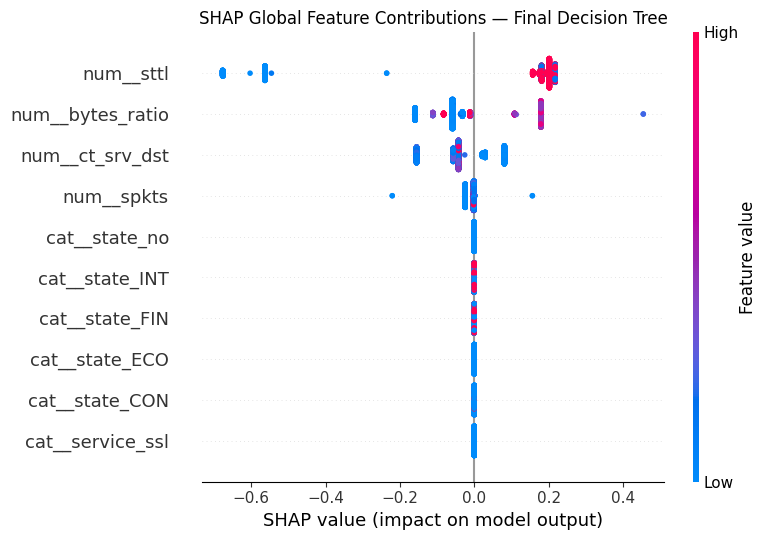

In [83]:
# Extract the fitted components of the final pipeline
decision_tree_model = final_model.named_steps["classifier"]
preprocessor = final_model.named_steps["preprocessor"]

# Transform the independent test set using the engineered feature set
X_test_transformed = preprocessor.transform(X_test_engineered)

# Use a sample of the test set for computational efficiency
shap_sample_size = min(2000, X_test_transformed.shape[0])

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    X_test_transformed.shape[0],
    size=shap_sample_size,
    replace=False
)

X_test_shap = X_test_transformed[sample_indices]

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Convert sparse matrix to dense format if necessary
if hasattr(X_test_shap, "toarray"):
    X_test_shap = X_test_shap.toarray()

# Create SHAP TreeExplainer
explainer = shap.TreeExplainer(decision_tree_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_shap)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Binary classification: select the malicious class (class 1)
    shap_values_plot = shap_values[:, :, 1]

else:
    shap_values_plot = shap_values

# Global SHAP summary plot
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_plot,
    X_test_shap,
    feature_names=feature_names,
    max_display=10,
    show=False
)

plt.title(
    "SHAP Global Feature Contributions — Final Decision Tree"
)

plt.tight_layout()
plt.show()

#### Interpretation of the results

The global SHAP analysis broadly confirms the feature importance results.

`sttl` shows the strongest overall contribution to the model's predictions, while `bytes_ratio` and `ct_srv_dst` also contribute to the predictions.

An important point is that the contribution of a feature can vary between observations. This provides more information than feature importance alone.

From an operational perspective, this means that the model does not simply rely on one fixed rule for every network connection. Different traffic observations can receive different contributions from the same features.

However, SHAP explains the behaviour of the trained model. It does not establish that these features cause malicious activity.

### 6.1.3 Local explanation of selected predictions

Global SHAP explanations describe the general behaviour of the model, but they do not explain why one specific network observation receives a particular prediction.

To illustrate this at observation level, two correctly classified test observations are examined:

- one malicious traffic observation;
- one normal traffic observation.

The observations come from the independent test set. The test set remains separate from model training, hyperparameter tuning, and threshold selection.

The objective is to show how different feature contributions are combined for an individual prediction.

In [84]:
# Select one correctly classified malicious observation
# and one correctly classified normal observation

# Generate final predictions using the selected threshold
y_test_proba = final_model.predict_proba(X_test_engineered)[:, 1]

y_test_pred = (
    y_test_proba >= selected_threshold
).astype(int)

# Identify correctly classified malicious observations
true_positive_positions = np.where(
    (y_test == 1) & (y_test_pred == 1)
)[0]

# Identify correctly classified normal observations
true_negative_positions = np.where(
    (y_test == 0) & (y_test_pred == 0)
)[0]

# Select one observation from each class
selected_positions = [
    true_positive_positions[0],
    true_negative_positions[0]
]

selected_labels = [
    "Correctly classified malicious traffic",
    "Correctly classified normal traffic"
]

print("Selected observations:")
print(
    f"Malicious observation position: {selected_positions[0]}"
)
print(
    f"Normal observation position: {selected_positions[1]}"
)

Selected observations:
Malicious observation position: 243
Normal observation position: 8


In [85]:
# Prepare the selected observations for local SHAP explanations

X_test_selected = X_test_transformed[selected_positions]

# Calculate SHAP values for the selected observations
selected_shap_values = explainer.shap_values(
    X_test_selected
)

# Handle different SHAP output formats
if isinstance(selected_shap_values, list):
    selected_shap_values_plot = selected_shap_values[1]

elif (
    isinstance(selected_shap_values, np.ndarray)
    and selected_shap_values.ndim == 3
):
    selected_shap_values_plot = selected_shap_values[:, :, 1]

else:
    selected_shap_values_plot = selected_shap_values

# Obtain the expected value for the malicious class
expected_value = explainer.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    expected_value = np.asarray(expected_value).reshape(-1)[-1]

print("Local SHAP values calculated successfully.")

Local SHAP values calculated successfully.



Correctly classified malicious traffic


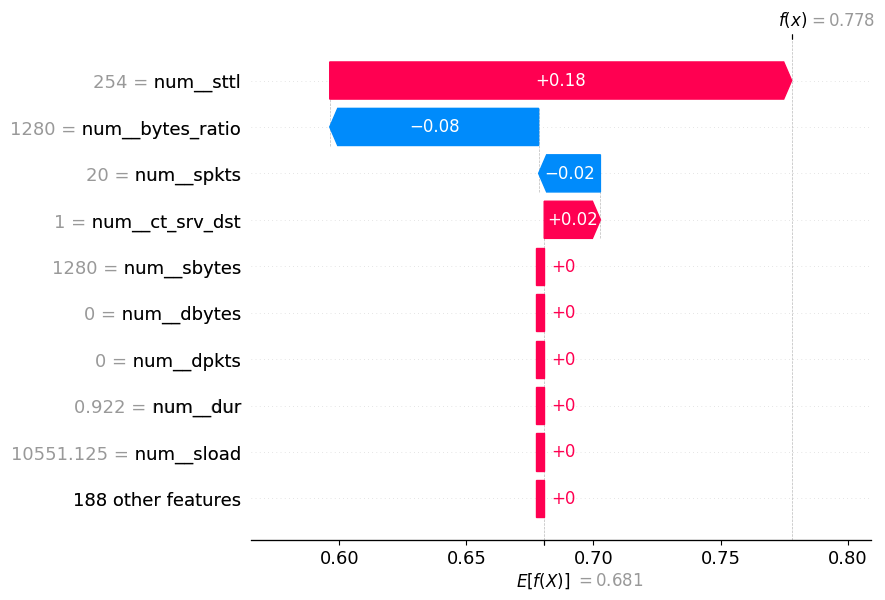


Correctly classified normal traffic


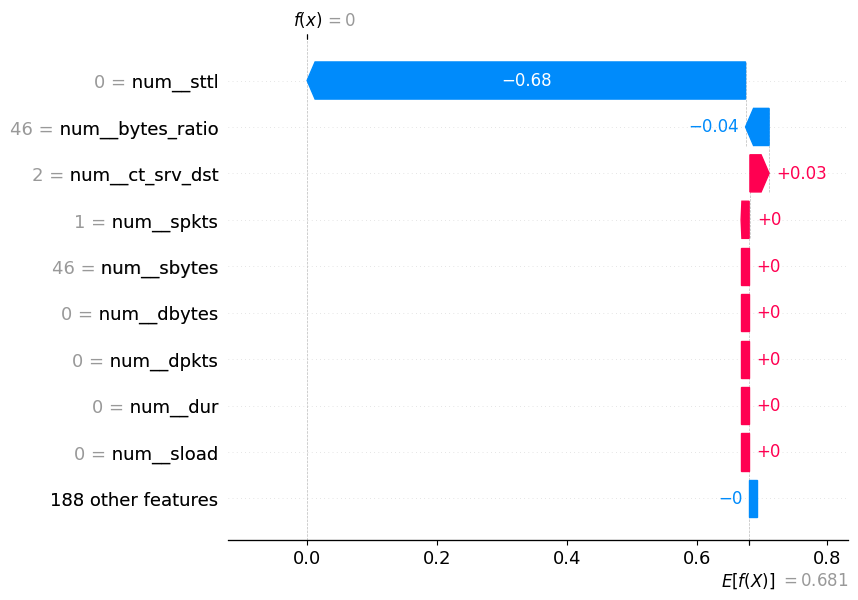

In [86]:
# Display local SHAP explanations

for i, position in enumerate(selected_positions):

    explanation = shap.Explanation(
        values=selected_shap_values_plot[i],
        base_values=expected_value,
        data=X_test_selected[i],
        feature_names=feature_names
    )

    print("\n" + "=" * 70)
    print(selected_labels[i])
    print("=" * 70)

    shap.plots.waterfall(
        explanation,
        max_display=10
    )

#### Interpretation of results

The local SHAP explanations show that the contribution of individual features can vary between network observations. For the selected correctly classified normal observation, `sttl` has a strong negative contribution of approximately **−0.68**, while `bytes_ratio` contributes approximately **−0.04** and `ct_srv_dst` approximately **+0.03**.

The selected correctly classified malicious observation shows a different distribution of feature contributions, with the displayed contributions remaining much closer to zero. This illustrates that individual predictions do not necessarily rely on the same combination or magnitude of feature contributions.

These explanations make individual model decisions more transparent, but they should be understood as explanations of the model's behaviour rather than causal explanations of network attacks.

### 6.1.4 Overall interpretation of model explainability

The explainability analysis shows that the final Decision Tree is relatively interpretable in the context of network intrusion detection. The model relies predominantly on a small number of network traffic characteristics, with `sttl` accounting for approximately **88.26%** of the total impurity-based feature importance, while the global and local SHAP analyses provide additional insight into how feature contributions vary across predictions.

This level of transparency is useful in a cybersecurity context because analysts can examine which characteristics of a network flow contributed to a classification rather than relying solely on an unexplained prediction. However, the strong concentration of importance on `sttl` also raises a robustness concern: if the relationship between this characteristic and malicious traffic changes in another network environment, the model's behaviour may also change.

The explainability analysis provides evidence that the model's decisions can be examined and interpreted, but it does not demonstrate that the model is reliable for operational deployment. The next sections therefore examine whether the model's performance is robust, whether potential limitations affect its generalisation, and what risks should be considered before using its predictions to support cybersecurity operations.

## 6.2 Model limitations and reliability

Good predictive performance does not automatically mean that a machine learning model is reliable in a real cybersecurity environment.

The objective of this section is therefore to identify the main factors that may affect the reliability and generalisation of the final Decision Tree.

Four points are considered:

- class imbalance;
- data leakage;
- overfitting and generalisation;
- limitations of the UNSW-NB15 dataset.

The key question is not only whether the model performs well on the available data, but also whether its behaviour could remain reliable when it encounters new network traffic.

### 6.2.1 Class imbalance

The training data contains more malicious traffic than normal traffic, with 68.06% malicious observations and 31.94% normal observations.

This imbalance does not prevent the binary classification task from being performed, but it is important when interpreting model performance.

In a cybersecurity context, the two types of errors do not have the same operational consequences:

- a false negative means that malicious traffic is not detected;
- a false positive means that legitimate traffic is incorrectly flagged and may generate an unnecessary alert.

For this reason, accuracy alone is not sufficient to evaluate the model. Recall, Precision, F1-score and False Positive Rate are also considered.

The class distribution is specific to the UNSW-NB15 dataset. A real network may have a very different proportion of malicious and legitimate traffic, which could affect both model performance and the resulting alert volume.

### 6.2.2 Data leakage

Data leakage occurs when information that would not realistically be available at prediction time is used by the model.

This is particularly important in network intrusion detection because leakage can produce artificially strong performance.

Two variables were excluded from the predictive feature set:

- `id`, because it is an identifier rather than a behavioural characteristic;
- `attack_cat`, because it contains attack-category information that could reveal information about the target label.

The preprocessing steps were also included inside the modelling pipelines. During cross-validation, transformations are therefore fitted using the training fold and then applied to the validation fold.

These safeguards reduce the risk of leakage within the modelling process.

However, they do not remove all possible sources of bias or dataset-related limitations. The final results should therefore still be interpreted in the context of the UNSW-NB15 dataset.

### 6.2.3 Overfitting and generalisation

Overfitting occurs when a model learns patterns that are too specific to the training data and performs less well on previously unseen observations.

In this cybersecurity context, generalisation is particularly important because an intrusion detection model must maintain its ability to distinguish malicious from legitimate traffic beyond the data used during development.

The final Decision Tree was evaluated on an independent test set that was not used for model training, hyperparameter tuning, or threshold selection.

| Metric | Out-of-fold validation | Independent test | Change |
|---|---:|---:|---:|
| Recall | 100.00% | 100.00% | 0.00 pp |
| Precision | 89.76% | 70.27% | -19.49 pp |
| F1-score | 94.60% | 82.54% | -12.06 pp |
| False Positive Rate | 24.31% | 51.84% | +27.53 pp |

The results show that Recall remains stable at 100.00%, but Precision and F1-score decrease and the False Positive Rate more than doubles on unseen data.

This means that the model generalises well for detecting the malicious observations represented in the test set, but less well for distinguishing legitimate traffic from malicious traffic.

The model shows imperfect generalisation and a potential overfitting concern, particularly regarding false positives. However, the results do not provide sufficient evidence to conclude that the model is severely overfitted. Further validation on representative real-world network traffic would be required before operational deployment.

### 6.2.4 Dataset limitations

The UNSW-NB15 dataset provides a useful benchmark for developing and evaluating an intrusion detection model.

However, it represents a specific experimental environment and does not reproduce all the characteristics of a real operational network.

Network traffic patterns, attack types, proportions of malicious traffic and legitimate user behaviour may differ between environments.

This is particularly relevant in this project because the final model relies heavily on a small number of traffic characteristics and shows different false-positive behaviour across traffic groups.

The results should therefore be interpreted as evidence of performance on the UNSW-NB15 benchmark, rather than as proof that the same performance would be achieved in another network.

Before operational deployment, the model would need to be validated using representative traffic from the target environment.

### 6.2.5 Key takeaway from the reliability analysis

The main limitation identified is not the ability to detect malicious traffic, but the stability of false-positive behaviour when the model is applied to unseen or different types of traffic.

This means that future validation should focus not only on maintaining high Recall, but also on understanding and reducing the operational alert burden.

The next section therefore examines whether model performance varies across different network-traffic groups.

### 6.3 Bias & fairness in a cybersecurity context

Fairness is usually discussed in relation to people or demographic groups. This is not directly applicable to the UNSW-NB15 dataset because the modelling data describes network traffic rather than individuals.

The dataset does not contain demographic or protected-group attributes. Therefore, conventional fairness measures such as demographic parity or equalised odds cannot be meaningfully applied here.

However, bias can still be relevant in a cybersecurity system. A model may perform differently depending on the type of network traffic being analysed.

The analysis therefore focuses on whether detection performance varies across different traffic groups, using protocol, service and connection state as group variables.

The objective is to identify potential differences in model behaviour that could create operational risks.

### 6.3.1 Why demographic fairness cannot be directly measured

The model is applied to network connections rather than individual people.

The available variables describe characteristics such as:

- network protocol;
- service;
- connection state;
- packet and traffic characteristics.

No demographic or protected attributes are available.

For this reason, this project cannot assess fairness across human demographic groups. The analysis instead focuses on differences in model performance across network-traffic groups.

### 6.3.2 Cybersecurity-oriented fairness audit

To examine whether model behaviour changes across different types of network traffic, the final model is evaluated separately for several traffic groups.

Three categorical variables are considered:

- `proto`: network protocol;
- `service`: network service;
- `state`: connection state.

The analysis is performed on the independent test set using the final model and the selected decision threshold.

For each group, Recall, Precision, F1-score and False Positive Rate are calculated.

These metrics are used to identify differences in detection behaviour rather than to measure demographic fairness.

In [87]:
# Generate predictions on the independent test set
y_test_proba = final_model.predict_proba(
    X_test_engineered
)[:, 1]

y_test_pred = (
    y_test_proba >= selected_threshold
).astype(int)


def calculate_group_metrics(
    X,
    y_true,
    y_pred,
    group_column
):
    """
    Calculate detection performance for each group
    of a categorical network-traffic variable.
    """

    results = []

    for group_value in X[group_column].dropna().unique():

        mask = X[group_column] == group_value

        y_group_true = np.asarray(y_true)[mask]
        y_group_pred = np.asarray(y_pred)[mask]

        support = len(y_group_true)

        # Confusion matrix components
        tn, fp, fn, tp = confusion_matrix(
            y_group_true,
            y_group_pred,
            labels=[0, 1]
        ).ravel()

        # Metrics
        recall = recall_score(
            y_group_true,
            y_group_pred,
            zero_division=0
        )

        precision = precision_score(
            y_group_true,
            y_group_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_group_true,
            y_group_pred,
            zero_division=0
        )

        # False Positive Rate
        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )

        results.append({
            "Group": group_value,
            "Support": support,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
            "FPR": fpr,
            "True_Positive": tp,
            "False_Negative": fn,
            "False_Positive": fp,
            "True_Negative": tn
        })

    return (
        pd.DataFrame(results)
        .sort_values(
            by="Support",
            ascending=False
        )
        .reset_index(drop=True)
    )


# Audit the three categorical network-traffic characteristics
protocol_group_metrics = calculate_group_metrics(
    X_test_engineered,
    y_test,
    y_test_pred,
    "proto"
)

service_group_metrics = calculate_group_metrics(
    X_test_engineered,
    y_test,
    y_test_pred,
    "service"
)

state_group_metrics = calculate_group_metrics(
    X_test_engineered,
    y_test,
    y_test_pred,
    "state"
)


print("Protocol-level performance:")
display(protocol_group_metrics.round(4))

print("\nService-level performance:")
display(service_group_metrics.round(4))

print("\nConnection-state-level performance:")
display(state_group_metrics.round(4))

Protocol-level performance:


,Group,Support,Recall,Precision,F1,FPR,True_Positive,False_Negative,False_Positive,True_Negative
0,tcp,43095,1.0,0.4935,0.6608,0.5620,15247,0,15650,12198
1,udp,29418,1.0,0.8590,0.9241,0.4323,21321,0,3500,4597
2,unas,3515,1.0,1.0000,1.0000,NaN,3515,0,0,0
3,arp,987,0.0,0.0000,0.0000,0.0000,0,0,0,987
4,ospf,676,1.0,1.0000,1.0000,0.0000,638,0,0,38
5,sctp,324,1.0,1.0000,1.0000,NaN,324,0,0,0
6,any,96,1.0,1.0000,1.0000,NaN,96,0,0,0
7,gre,88,1.0,1.0000,1.0000,NaN,88,0,0,0
8,rsvp,64,1.0,1.0000,1.0000,NaN,64,0,0,0
9,ipv6,61,1.0,1.0000,1.0000,NaN,61,0,0,0



Service-level performance:


,Group,Support,Recall,Precision,F1,FPR,True_Positive,False_Negative,False_Positive,True_Negative
0,-,47153,1.0,0.5470,0.7071,0.5984,19778,0,16382,10993
1,dns,21367,1.0,0.9999,0.9999,0.0007,18299,0,2,3066
2,http,8287,1.0,0.6441,0.7835,0.5886,4274,0,2362,1651
3,smtp,1851,1.0,1.0000,1.0000,0.0000,1216,0,0,635
4,ftp,1552,1.0,0.6476,0.7861,0.5699,794,0,432,326
5,ftp-data,1396,1.0,1.0000,1.0000,0.0000,447,0,0,949
6,pop3,423,1.0,1.0000,1.0000,NaN,423,0,0,0
7,ssh,204,1.0,1.0000,1.0000,0.0000,4,0,0,200
8,ssl,30,1.0,1.0000,1.0000,NaN,30,0,0,0
9,snmp,29,1.0,1.0000,1.0000,NaN,29,0,0,0



Connection-state-level performance:


,Group,Support,Recall,Precision,F1,FPR,True_Positive,False_Negative,False_Positive,True_Negative
0,FIN,39339,1.0,0.5569,0.7154,0.4992,15167,0,12067,12105
1,INT,34163,1.0,0.8941,0.9441,0.7837,29678,0,3515,970
2,CON,6982,1.0,0.1533,0.2659,0.2905,349,0,1927,4706
3,REQ,1842,1.0,0.0748,0.1392,0.9783,135,0,1670,37
4,ACC,4,1.0,1.0000,1.0000,0.0000,2,0,0,2
5,RST,1,0.0,0.0000,0.0000,1.0000,0,0,1,0
6,CLO,1,1.0,1.0000,1.0000,NaN,1,0,0,0


In [88]:
# Keep sufficiently represented traffic groups for the main fairness audit

MIN_SUPPORT = 500

protocol_audit = protocol_group_metrics[
    protocol_group_metrics["Support"] >= MIN_SUPPORT
].copy()

service_audit = service_group_metrics[
    service_group_metrics["Support"] >= MIN_SUPPORT
].copy()

state_audit = state_group_metrics[
    state_group_metrics["Support"] >= MIN_SUPPORT
].copy()


# Keep only the metrics needed for interpretation
audit_columns = [
    "Group",
    "Support",
    "Recall",
    "Precision",
    "F1",
    "FPR"
]

protocol_audit = protocol_audit[audit_columns]
service_audit = service_audit[audit_columns]
state_audit = state_audit[audit_columns]


print("Protocol-level audit:")
display(protocol_audit.round(4))

print("\nService-level audit:")
display(service_audit.round(4))

print("\nConnection-state-level audit:")
display(state_audit.round(4))

Protocol-level audit:


,Group,Support,Recall,Precision,F1,FPR
0,tcp,43095,1.0,0.4935,0.6608,0.5620
1,udp,29418,1.0,0.8590,0.9241,0.4323
2,unas,3515,1.0,1.0000,1.0000,NaN
3,arp,987,0.0,0.0000,0.0000,0.0000
4,ospf,676,1.0,1.0000,1.0000,0.0000



Service-level audit:


,Group,Support,Recall,Precision,F1,FPR
0,-,47153,1.0,0.5470,0.7071,0.5984
1,dns,21367,1.0,0.9999,0.9999,0.0007
2,http,8287,1.0,0.6441,0.7835,0.5886
3,smtp,1851,1.0,1.0000,1.0000,0.0000
4,ftp,1552,1.0,0.6476,0.7861,0.5699
5,ftp-data,1396,1.0,1.0000,1.0000,0.0000



Connection-state-level audit:


,Group,Support,Recall,Precision,F1,FPR
0,FIN,39339,1.0,0.5569,0.7154,0.4992
1,INT,34163,1.0,0.8941,0.9441,0.7837
2,CON,6982,1.0,0.1533,0.2659,0.2905
3,REQ,1842,1.0,0.0748,0.1392,0.9783


In [89]:
# Add class-specific support to the group-level audit

def add_class_support(audit_df, X, y_true, group_column):

    rows = []

    y_array = np.asarray(y_true)

    for group_value in audit_df["Group"]:

        mask = X[group_column] == group_value

        group_y = y_array[mask]

        malicious_support = int((group_y == 1).sum())
        normal_support = int((group_y == 0).sum())

        rows.append({
            "Group": group_value,
            "Malicious Support": malicious_support,
            "Normal Support": normal_support
        })

    support_df = pd.DataFrame(rows)

    return audit_df.merge(
        support_df,
        on="Group",
        how="left"
    )


protocol_audit = add_class_support(
    protocol_audit,
    X_test_engineered,
    y_test,
    "proto"
)

service_audit = add_class_support(
    service_audit,
    X_test_engineered,
    y_test,
    "service"
)

state_audit = add_class_support(
    state_audit,
    X_test_engineered,
    y_test,
    "state"
)


# Reorder columns for readability

audit_columns = [
    "Group",
    "Support",
    "Malicious Support",
    "Normal Support",
    "Recall",
    "Precision",
    "F1",
    "FPR"
]

protocol_audit = protocol_audit[audit_columns]
service_audit = service_audit[audit_columns]
state_audit = state_audit[audit_columns]


print("Protocol-level audit:")
display(protocol_audit.round(4))

print("\nService-level audit:")
display(service_audit.round(4))

print("\nConnection-state-level audit:")
display(state_audit.round(4))

Protocol-level audit:


,Group,Support,Malicious Support,Normal Support,Recall,Precision,F1,FPR
0,tcp,43095,15247,27848,1.0,0.4935,0.6608,0.5620
1,udp,29418,21321,8097,1.0,0.8590,0.9241,0.4323
2,unas,3515,3515,0,1.0,1.0000,1.0000,NaN
3,arp,987,0,987,0.0,0.0000,0.0000,0.0000
4,ospf,676,638,38,1.0,1.0000,1.0000,0.0000



Service-level audit:


,Group,Support,Malicious Support,Normal Support,Recall,Precision,F1,FPR
0,-,47153,19778,27375,1.0,0.5470,0.7071,0.5984
1,dns,21367,18299,3068,1.0,0.9999,0.9999,0.0007
2,http,8287,4274,4013,1.0,0.6441,0.7835,0.5886
3,smtp,1851,1216,635,1.0,1.0000,1.0000,0.0000
4,ftp,1552,794,758,1.0,0.6476,0.7861,0.5699
5,ftp-data,1396,447,949,1.0,1.0000,1.0000,0.0000



Connection-state-level audit:


,Group,Support,Malicious Support,Normal Support,Recall,Precision,F1,FPR
0,FIN,39339,15167,24172,1.0,0.5569,0.7154,0.4992
1,INT,34163,29678,4485,1.0,0.8941,0.9441,0.7837
2,CON,6982,349,6633,1.0,0.1533,0.2659,0.2905
3,REQ,1842,135,1707,1.0,0.0748,0.1392,0.9783


In [90]:
# Quantify performance variation across sufficiently represented groups

def summarize_audit_variation(audit_df, group_type):

    # Recall is only interpretable when malicious observations exist
    recall_valid = audit_df[
        audit_df["Malicious Support"] > 0
    ]

    # FPR is only interpretable when normal observations exist
    fpr_valid = audit_df[
        audit_df["Normal Support"] > 0
    ]

    summary = {
        "Group type": group_type,

        "Recall range": (
            recall_valid["Recall"].max()
            - recall_valid["Recall"].min()
        ),

        "Precision range": (
            audit_df["Precision"].max()
            - audit_df["Precision"].min()
        ),

        "F1 range": (
            audit_df["F1"].max()
            - audit_df["F1"].min()
        ),

        "FPR range": (
            fpr_valid["FPR"].max()
            - fpr_valid["FPR"].min()
        ),

        "Highest FPR": fpr_valid["FPR"].max(),

        "Lowest FPR": fpr_valid["FPR"].min(),

        "Lowest Precision": audit_df["Precision"].min()
    }

    return summary


fairness_variation_summary = pd.DataFrame([
    summarize_audit_variation(
        protocol_audit,
        "Protocol"
    ),
    summarize_audit_variation(
        service_audit,
        "Service"
    ),
    summarize_audit_variation(
        state_audit,
        "Connection state"
    )
])

display(
    fairness_variation_summary.round(4)
)

,Group type,Recall range,Precision range,F1 range,FPR range,Highest FPR,Lowest FPR,Lowest Precision
0,Protocol,0.0,1.0000,1.0000,0.5620,0.5620,0.0000,0.0000
1,Service,0.0,0.4530,0.2929,0.5984,0.5984,0.0000,0.5470
2,Connection state,0.0,0.8193,0.8049,0.6878,0.9783,0.2905,0.0748


### 6.3.3 Interpretation of the group-level audit

The audit shows that model performance is not identical across all traffic groups.

Recall is very high for most groups represented in the test set, but Precision and False Positive Rate vary substantially across protocols, services and connection states.

For example, TCP traffic has a Precision of 0.4935 and an FPR of 0.5620, while UDP has a higher Precision of 0.8590 and a lower FPR of 0.4323.

The differences are even more visible for connection states. The `REQ` group has a Precision of 0.0748 and an FPR of 0.9783, meaning that a large proportion of legitimate traffic in this group is classified as malicious.

These results do not demonstrate demographic bias. Instead, they identify differences in detection behaviour across types of network traffic.

From an operational perspective, this matters because a security team could receive a very different number of alerts depending on the type of traffic being monitored. High false-positive rates in specific groups could increase analyst workload and reduce the efficiency of alert investigation.

### 6.3.4 Key takeaway from the bias and fairness audit

The analysis does not provide evidence about demographic fairness because the dataset does not contain demographic information.

It does, however, show that model behaviour can vary across types of network traffic, particularly in terms of Precision and False Positive Rate.

For a cybersecurity deployment, these differences should be monitored because they may affect the number of alerts generated and the workload of security analysts.

Before operational use, traffic groups showing high false-positive rates should be investigated and validated using representative data from the target environment.

### 6.4 From model performance to operational risk

Machine learning metrics describe how well a model predicts the target, but they do not directly describe what would happen if the model were used in a cybersecurity environment.

For an intrusion detection system, two types of errors are particularly important:

- **False negatives:** malicious traffic is classified as normal and an attack may remain undetected.
- **False positives:** legitimate traffic is classified as malicious and generates an unnecessary alert.

The operational value of the model therefore depends on both detection effectiveness and the volume of alerts generated for security analysts.

In [91]:
# Operational indicators: missed attacks

undetected_attack_rate = 1 - final_recall

print(f"Malicious Traffic Detection Rate: {final_recall:.2%}")
print(f"Undetected Attack Rate: {undetected_attack_rate:.2%}")
print(f"False Negatives: {fn}")

Malicious Traffic Detection Rate: 100.00%
Undetected Attack Rate: 0.00%
False Negatives: 0


### 6.4.1 False negatives and undetected attacks

False negatives are particularly important in an intrusion detection context because they represent malicious traffic that the model fails to identify.

On the independent test set, the final Decision Tree achieved:

- Malicious Traffic Detection Rate: 100%
- Undetected Attack Rate: 0%
- False Negatives: 0

This means that all malicious observations in this test set were identified by the model at the selected threshold.

From an operational perspective, this is an important result because missing an attack can have serious consequences.

However, this result should be interpreted within the limits of the UNSW-NB15 test set. It does not mean that the model would detect every attack in a different real-world network.

In [92]:
# Operational impact of false positives

legitimate_traffic = tn + fp

false_alert_rate = (
    fp / legitimate_traffic
    if legitimate_traffic > 0
    else np.nan
)

alerts_per_10000_flows = (
    fp / len(y_test) * 10000
)

print(f"False Positive Rate: {false_alert_rate:.2%}")
print(f"False Positive Alerts: {fp}")
print(f"Legitimate Traffic: {legitimate_traffic}")
print(f"Alerts per 10,000 Network Flows: {alerts_per_10000_flows:.2f}")

False Positive Rate: 51.84%
False Positive Alerts: 19180
Legitimate Traffic: 37000
Alerts per 10,000 Network Flows: 2329.59


### 6.4.2 False positives and analyst workload

False positives represent legitimate network traffic that is incorrectly classified as malicious.

Unlike false negatives, false positives mainly create an operational burden. Each alert may require investigation by a cybersecurity analyst before it can be dismissed or escalated.

On the independent test set, the final Decision Tree produced:

- False Positive Rate: 51.84%
- False Positive Alerts: 19,180
- Legitimate Traffic: 37,000
- approximately 2,330 false alerts per 10,000 network flows.

This means that the model's strong detection performance is accompanied by a significant alert burden.

The group-level analysis also showed that this burden is not evenly distributed across traffic types. Some groups, such as the `REQ` connection state, produced particularly high False Positive Rates.

From an operational perspective, this is important because a high number of false alerts can increase analyst workload and make it more difficult to focus attention on genuinely suspicious activity.

### 6.4.3 Operational KPI interpretation

The results show two different operational dimensions that need to be considered together.

**Detection effectiveness**

- Malicious Traffic Detection Rate: 100%
- Undetected Attack Rate: 0%

**Alert burden**

- False Positive Rate: 51.84%
- False Positive Alerts: 19,180
- approximately 2,330 false alerts per 10,000 network flows.

The model therefore demonstrates strong detection of malicious traffic on the independent test set, but it also generates a substantial number of false alerts.

This shows why a cybersecurity detection system should not be evaluated using Recall alone.

For an operational deployment, both missed attacks and alert volume would need to be monitored continuously.

### 6.4.4  Key takeaway from the operational risk analysis

The final model illustrates a clear trade-off between detection and alert burden.

Its Recall of 100% means that no malicious observations were missed on the independent test set. However, the False Positive Rate of 51.84% means that a large number of legitimate observations were also flagged.

The main operational challenge is therefore not only detecting attacks, but doing so while keeping the number of unnecessary alerts manageable for security analysts.

The next section considers possible ways to reduce these risks.

### 6.5 Mitigation strategies

The previous analysis identified several risks, particularly the high False Positive Rate and differences in model behaviour across traffic groups.

The purpose of mitigation is not to remove all errors, which is unrealistic, but to reduce the main operational risks identified in this project.

Four possible mitigation approaches are considered:

- improving the training data;
- improving the model;
- adjusting the decision threshold;
- keeping human oversight in the detection process.

### 6.5.1 Data-level mitigation

The first area for improvement is the data itself.

The UNSW-NB15 dataset represents a specific experimental environment. Before using the model in an operational setting, the training data should therefore be complemented with representative traffic from the target environment.

Particular attention should be given to traffic groups where the current model produces high False Positive Rates.

A more representative dataset could help the model learn patterns that are closer to the traffic encountered in practice.

This would also make it possible to evaluate whether the observed performance differences remain present in the target environment.

### 6.5.2 Model-level mitigation

A second option would be to evaluate alternative models or model configurations if the false-positive problem remains significant.

The current project selected a shallow Decision Tree because it provided a good balance between predictive performance and interpretability.

However, future work could investigate whether another model or a different configuration could reduce false positives while maintaining a high Recall.

Any new model should be evaluated using the same independent test strategy and the same operational metrics.

### 6.5.3 Threshold adjustment

The decision threshold determines how easily the model classifies an observation as malicious.

A lower threshold generally makes the detection system more sensitive, while a higher threshold can reduce the number of alerts but may increase the risk of missed attacks.

The appropriate threshold therefore depends on the operational objective.

In a cybersecurity environment, threshold selection should be based on the acceptable balance between missed attacks and analyst workload rather than on a single metric such as Accuracy.

### 6.5.4 Human-in-the-loop

The results of this project suggest that the model should be used as a decision-support tool rather than as a fully autonomous security system.

The model can help identify suspicious traffic and prioritise observations for investigation.

A security analyst can then review the alert and decide whether further action is required.

This approach is particularly relevant because the model combines very high detection performance with a significant False Positive Rate.

Human review can therefore help manage the consequences of false alerts while keeping the model useful for detecting potentially malicious traffic.

### 6.5.5 Key takeaway from the mitigation analysis

The main improvement opportunity identified in this project is to reduce false alerts without significantly reducing the ability to detect malicious traffic.

The most realistic approach would combine better representative data, continued model evaluation, appropriate threshold selection and human review.

These measures should be validated using representative traffic before considering operational deployment.

## 6.6 Critical reflection

The final Decision Tree demonstrates strong malicious-traffic detection on the independent test set, achieving 100% Recall and zero false negatives.

However, this performance is accompanied by a substantial false-positive burden, with a False Positive Rate of 51.84% and 19,180 legitimate observations incorrectly classified as malicious.

The analysis also showed that false-positive behaviour varies considerably across network-traffic groups, while the generalisation analysis identified differences between validation and independent-test performance.

The model can therefore provide useful support for cybersecurity analysts, particularly for detecting and prioritising potentially malicious traffic. However, the current results do not provide sufficient evidence for autonomous operational use.

Further validation on representative operational traffic, monitoring of false-positive behaviour, and continued human oversight would be required before deployment in a real cybersecurity environment.